# 3.0 Data Distributions
---
---
I am going to do everything in this notebook and then split it up into more relevant notebooks since I want:
- 3 Foundation, make the customer dataset
- 3 Firmographic, make country regions
- 3 Lifecycle / Value, basic RFM
- 3 Seasonal, Pareto, trajectory
- 4 Behavioural, shopping patterns --> persona backbone
- 5 Product Affinity, what can I get from the descriptions
- 6 Triangulation, determine suitable personas from 1 - 4 and define business value
- 7 Validation and testing and look for business relevant storyline

Once I see how all the above sits I can edit the portfolio appropriately

# Table Specifications
---
---

#### **Table name:** cleansed_retail_orders
- Fields: 15
- Rows: 1.067,371
- File Size: 9.5MB
- Approximate Memory Use: 256 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | Str | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| Str | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | Str | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Int 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | Str | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | Str | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Bool | This is a True/False flag | False |
| InvoiceDateMin | Remove system timing issue from Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| StockCodeType | Name of what it is, if not a stock code | Str | This is a string | Postage |
| DescriptionType | Summary of what it is, if not a stock code description | Str | This is a string | Damages |
| WarehouseInventory | These are warehouse stock control | Str | This is a string | Add Stock |
| CancellationType | More detail into what the cancellation is | Str | This is a string | Full Invoice Re-Key |
| OrderCheckout | Who raised the order | Str | This is a string | Customer Account |

---
# Load Data
---
---
First we need to load the data ready for Plotting Graphs:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/cleansed_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing df_cleansed_online_retail_orders ..")
    df_cleansed_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.")

⏳ Importing df_cleansed_online_retail_orders ..
✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.


---
---
# Distribution Analysis

In [2]:
# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply customer base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# Define 12-month cutoff and create trailing twelve month (LTM) Revenue column
max_date = df['InvoiceDateMin'].max()
ltm_cutoff = max_date - pd.Timedelta(days=365)

# If the invoice is in the last 365 days, keep the price. Otherwise, set it to 0.
df['ltm_revenue_raw'] = np.where(df['InvoiceDateMin'] >= ltm_cutoff, df['TotalPrice'], 0)

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# Customer-level aggregations
customer = df.groupby('CustomerHashID').agg(
    n_invoices         = ('Invoice',         'nunique'),
    n_lines            = ('Invoice',         'size'),
    n_skus             = ('StockCode',       'nunique'),
    total_qty          = ('Quantity',        'sum'),
    total_revenue      = ('TotalPrice',      'sum'),
    ltm_revenue        = ('ltm_revenue_raw', 'sum'), 
    avg_qty_per_line   = ('Quantity',        'mean'),
    median_qty_per_line= ('Quantity',        'median'),
    max_qty_per_line   = ('Quantity',        'max'),
    first_purchase     = ('InvoiceDateMin',  'min'),
    last_purchase      = ('InvoiceDateMin',  'max'),
    n_countries        = ('Country',         'nunique'),
).reset_index()

customer['total_revenue'] = customer['total_revenue'].round(2)
customer['ltm_revenue'] = customer['ltm_revenue'].round(2)

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID')
)

# Calculate average item value
customer['avg_item_value'] = customer['total_revenue'] / customer['total_qty']

# we don't know tenure so we use active span for the trading window, between first and last purchase (min 1 day)
customer['active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)

# To handle first day orders defaulting to 30.44 orders force the minimum window to be 1 month (30.44 days)
math_span_days = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=30.44)
customer['orders_per_month'] = customer['n_invoices'] / (math_span_days / 30.44)

customer['recency_days']     = (df['InvoiceDateMin'].max() - customer['last_purchase']).dt.days
customer['repeat_customer']  = customer['n_invoices'] > 1

# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')


# we flag customers first purchase within 30 days of window as left-censored since we don'k know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)

print(customer.shape)
customer.head()

(5849, 23)


,CustomerHashID,n_invoices,n_lines,n_skus,total_qty,total_revenue,ltm_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,...,avg_basket_breadth,avg_basket_value,avg_basket_qty,avg_item_value,active_span_days,orders_per_month,recency_days,repeat_customer,cohort_month,is_left_censored
0,00189f7baec2462e442b86d14102254df902adc5accc25...,11,189,172,2165,3349.57,3349.57,11.455026,12.0,48,...,17.181818,304.506364,196.818182,1.547145,194,1.725979,10,True,2011-05,False
1,002403301211297ae25ec229d6751c749330628e52940b...,9,115,30,1955,4049.79,1405.78,17.000000,16.0,40,...,12.777778,449.976667,217.222222,2.071504,559,0.490089,108,True,2010-02,False
2,0029315aefcd3710655f212f0d3b621343af84f1cf7aee...,4,9,3,162,420.30,420.30,18.000000,24.0,24,...,2.250000,105.075000,40.500000,2.594444,265,0.459472,9,True,2011-03,False
3,0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...,6,12,7,1233,1133.25,1133.25,102.750000,50.0,200,...,2.000000,188.875000,205.500000,0.919100,143,1.277203,6,True,2011-07,False
4,00386273912716004a52cf88eca0d3db7fb54734d0601f...,1,45,45,386,1693.88,1693.88,8.577778,8.0,24,...,45.000000,1693.880000,386.000000,4.388290,1,1.000000,316,False,2011-01,False


---
---
## First let's quantify B2B versus B2C customer profile

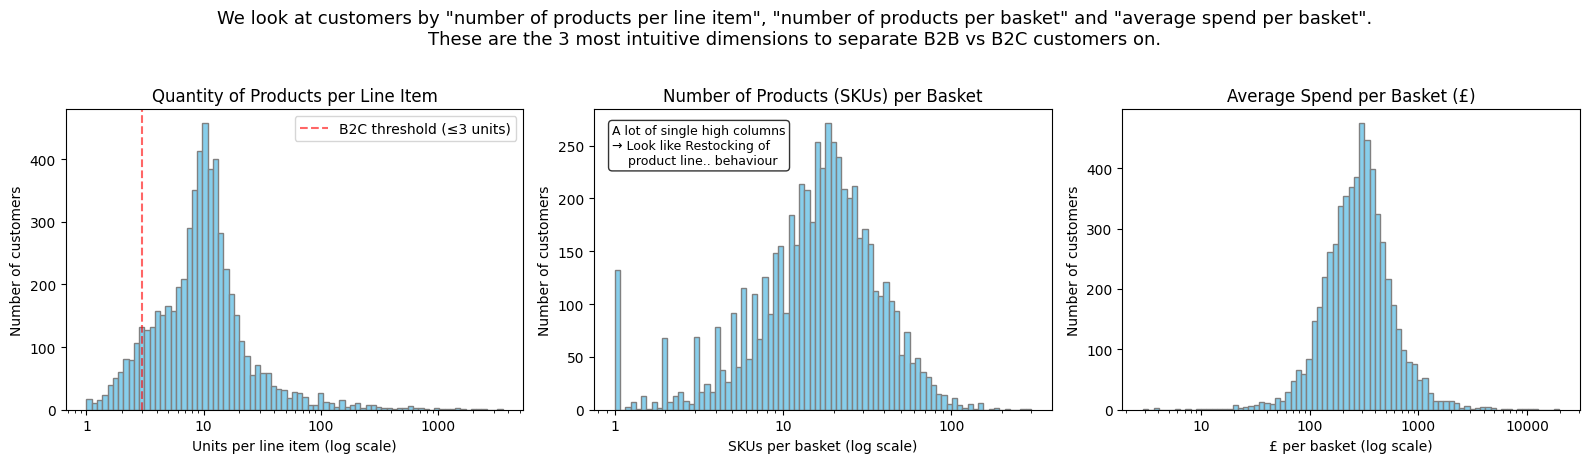

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bins      = 80          # fewer bins on a log scale reads cleaner
color     = 'skyblue'
edgecolor = 'grey'

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('We look at customers by "number of products per line item", "number of products per basket" and "average spend per basket".\nThese are the 3 most intuitive dimensions to separate B2B vs B2C customers on.',
             fontsize=13, y=1.02)

# ── Plot 1: Avg quantity per line ─────────────────────────────────────────
# Use log-spaced bins so the histogram is evenly distributed on a log axis
qty   = customer['avg_qty_per_line'].clip(lower=0.5)
edges = np.logspace(np.log10(qty.min()), np.log10(qty.max()), bins)

ax[0].hist(qty, bins=edges, color=color, edgecolor=edgecolor)
ax[0].set_xscale('log')
ax[0].set_title('Quantity of Products per Line Item')
ax[0].set_xlabel('Units per line item (log scale)')
ax[0].set_ylabel('Number of customers')
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())  # show 1, 10, 100 not 10^0

ax[0].axvline(3, color='red', ls='--', alpha=0.6,
              label='B2C threshold (≤3 units)')
ax[0].legend()


# ── Plot 2: Avg basket breadth ────────────────────────────────────────────
brd   = customer['avg_basket_breadth'].clip(lower=0.5)
edges = np.logspace(np.log10(brd.min()), np.log10(brd.max()), bins)

ax[1].hist(brd, bins=edges, color=color, edgecolor=edgecolor)
ax[1].set_xscale('log')
ax[1].set_title('Number of Products (SKUs) per Basket')
ax[1].set_xlabel('SKUs per basket (log scale)')
ax[1].set_ylabel('Number of customers')
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())

ax[1].text(0.04, 0.95, 'A lot of single high columns\n→ Look like Restocking of\n    product line.. behaviour',
           transform=ax[1].transAxes, va='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── Plot 3: Avg basket value ──────────────────────────────────────────────
val   = customer['avg_basket_value'].clip(lower=1)
edges = np.logspace(np.log10(val.min()), np.log10(val.max()), bins)

ax[2].hist(val, bins=edges, color=color, edgecolor=edgecolor)
ax[2].set_xscale('log')
ax[2].set_title('Average Spend per Basket (£)')
ax[2].set_xlabel('£ per basket (log scale)')
ax[2].set_ylabel('Number of customers')
ax[2].xaxis.set_major_formatter(mticker.ScalarFormatter())


plt.tight_layout()
plt.show()

---
There is nothing obvious in the above to suggest B2C customers ..
- Let's plot item quantity versus basket breadth to see if there is any significant B2C concentration in the bottom left corner

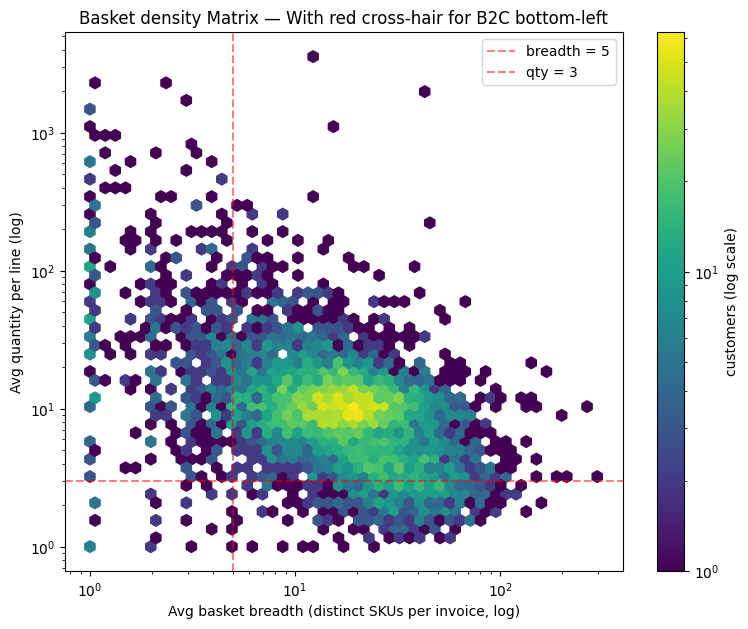

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

x = customer['avg_basket_breadth'].clip(lower=0.5)
y = customer['avg_qty_per_line'].clip(lower=0.5)

fig, ax = plt.subplots(figsize=(9,7))
hb = ax.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
               norm=LogNorm(), cmap='viridis', mincnt=1)
ax.set_xlabel('Avg basket breadth (distinct SKUs per invoice, log)')
ax.set_ylabel('Avg quantity per line (log)')
ax.set_title('Basket density Matrix — With red cross-hair for B2C bottom-left')
plt.colorbar(hb, ax=ax, label='customers (log scale)')

# Reference lines for a "B2C-like" zone
ax.axvline(5, color='red', ls='--', alpha=0.5, label='breadth = 5')
ax.axhline(3, color='red', ls='--', alpha=0.5, label='qty = 3')
ax.legend()
plt.show()

Those 4 graphs suggest this company is B2B only. 
- Even the 10^0 cluster far left is a vertical line going high on quantity suggesting stock replenishment for one or several products.

---
# Check for B2C specifically

In [5]:
b2c_candidates = customer[
    (customer['avg_qty_per_line']   <= 2)   &
    (customer['avg_basket_breadth'] >= 3)   &
    (customer['avg_basket_breadth'] <= 25)  &
    (customer['avg_basket_value']   <= 50)  &
    (customer['n_invoices']         <= 2)
].copy()

print(f"B2C-likeliest candidates: {len(b2c_candidates)} of {len(customer)} "
      f"({len(b2c_candidates)/len(customer):.1%})")

if len(b2c_candidates):
    cand_tx = df[df['CustomerHashID'].isin(b2c_candidates['CustomerHashID'])]
    print("\nTop products they buy:")
    print(cand_tx.groupby('Description').size()
                  .sort_values(ascending=False).head(20))
    print("\nCountry mix (by customer):")
    print("\nMedian profile:")
    print(b2c_candidates[['avg_basket_breadth','avg_qty_per_line',
                          'avg_basket_value','total_revenue']].median().round(2))

B2C-likeliest candidates: 6 of 5849 (0.1%)

Top products they buy:
Description
CHILLI LIGHTS                         2
AIRLINE BAG VINTAGE WORLD CHAMPION    1
RAIN PONCHO                           1
TEA TIME PARTY BUNTING                1
TABLECLOTH RED APPLES DESIGN          1
SWEETHEART 3 TIER CAKE STAND          1
SET OF 3 BLACK FLYING DUCKS           1
SEASIDE FLYING DISC                   1
SAVOY ART DECO CLOCK                  1
S 4 GROOVY CAT MAGNETS                1
ROSE DU SUD WASHBAG                   1
REX CASH CARRY JUMBO SHOPPER          1
RED WHITE DOTS RUFFLED UMBRELLA       1
RED SPOTTY WASHBAG                    1
RED HEARTS LIGHT CHAIN                1
RAIN PONCHO RETROSPOT                 1
PINK KNITTED COW STUFFED TOY          1
ALARM CLOCK BAKELIKE GREEN            1
PINK JUMPER LARRY THE LAMB            1
PARTY BUNTING                         1
dtype: int64

Country mix (by customer):

Median profile:
avg_basket_breadth     5.00
avg_qty_per_line       1.20
avg_bas

---
---
# We add more useful fields for analysis downstream

---
## Percentage case packs
 We add pack_size, is_pack_sku, is_case_pack_line_wholesale and is_case_pack_line_metric to identify bulk B2B purchases and purchase of sets
 - We split case-pack detection into two feature families: traditional UK wholesale multiples (base-6/12) and metric/Asian manufacturing multiples (base-5/10).
 - We also identify line items that themselves are packs

In [3]:
import re
import pandas as pd

# Traditional UK/European Wholesale (Base-6 / Base-12) common case pack multiples in B2B
pack_multiples_wholesale =[6, 12, 24, 36, 48, 72, 96, 120, 144, 288, 576]

# Modern/Asian Manufacturing (Base-5 / Base-10) common case pack multiples in B2B
pack_multiples_metric =[5, 10, 20, 50, 100, 500, 1000]

WORD_TO_NUM = {
    'TWO': 2, 'THREE': 3, 'FOUR': 4, 'FIVE': 5, 'SIX': 6,
    'SEVEN': 7, 'EIGHT': 8, 'NINE': 9, 'TEN': 10,
    'ELEVEN': 11, 'TWELVE': 12, 'FIFTEEN': 15, 'TWENTY': 20,
}

# 1. Pull pack size from Description (defaults to 1 = single) — kept on df for later use
# (PACK|SET|BOX), optionally OF, then either digits or a known number word
pack_pattern = re.compile(
    r'\b(?:PACK|SET|BOX)\s+(?:OF\s+)?(\d+|' + '|'.join(WORD_TO_NUM) + r')\b',
    re.IGNORECASE,
)

def detect_pack_size(desc):
    if pd.isna(desc):
        return 1
    m = pack_pattern.search(str(desc).upper())
    if not m:
        return 1
    val = m.group(1).upper()
    return int(val) if val.isdigit() else WORD_TO_NUM.get(val, 1)

df['pack_size']   = df['Description'].apply(detect_pack_size)
df['is_pack_sku'] = df['pack_size'] > 1


# Flag line as case-pack only if Quantity exactly matches one of these values
df['is_case_pack_line_wholesale'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_wholesale)
df['is_case_pack_line_metric'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_metric)


# 3. Aggregate to customer
pct_case_pack_wholesale = (df.groupby('CustomerHashID')['is_case_pack_line_wholesale']
                   .mean()
                   .rename('pct_case_pack_wholesale')
                   )
pct_case_pack_metric = (df.groupby('CustomerHashID')['is_case_pack_line_metric']
                   .mean()
                   .rename('pct_case_pack_metric')
                   )

# Merge into customer dataframe
customer = customer.merge(pct_case_pack_wholesale, on='CustomerHashID', how='left')
customer = customer.merge(pct_case_pack_metric, on='CustomerHashID', how='left')

# Calculate the total
customer['pct_case_pack_total'] = customer['pct_case_pack_wholesale'].fillna(0) + customer['pct_case_pack_metric'].fillna(0)


## We add percentage orders during business hours (UK) or evening weekend
- `pct_business_hours` and `pct_weekend` from `InvoiceDateMin`

In [4]:
# Business hours = Mon-Fri (weekday 0-4), 08:00 to 17:59 inclusive
# Evening hours = Mon-Fri 18:00-07:59 
# Weekends = Sat-Sun any time
# Treating all timestamps as UK time. No time saving hour change observed.

df['order_hour']    = df['InvoiceDateMin'].dt.hour
df['order_weekday'] = df['InvoiceDateMin'].dt.weekday   # 0=Mon, 6=Sun


is_weekday = df['order_weekday'].between(0, 4)

df['is_business_hours']    = is_weekday & df['order_hour'].between(8, 17)   # Mon-Fri 08:00-17:59
df['is_after_hours_wkday'] = is_weekday & ~df['order_hour'].between(8, 17)  # Mon-Fri 18:00-07:59
df['is_weekend']           = df['order_weekday'] >= 5                       # Sat-Sun any time


pct_hours = df.groupby('CustomerHashID').agg(
    pct_business_hours    = ('is_business_hours',    'mean'),
    pct_after_hours_wkday = ('is_after_hours_wkday', 'mean'),
    pct_weekend           = ('is_weekend',           'mean'),
)

customer = customer.drop(columns=['pct_business_hours','pct_after_hours_wkday','pct_weekend'], errors='ignore')
customer = customer.merge(pct_hours, on='CustomerHashID', how='left')

I should include the below but put it in a feature data validation section at the bottom

<Axes: title={'center': 'Order hour by BST vs GMT period'}, xlabel='order_hour'>

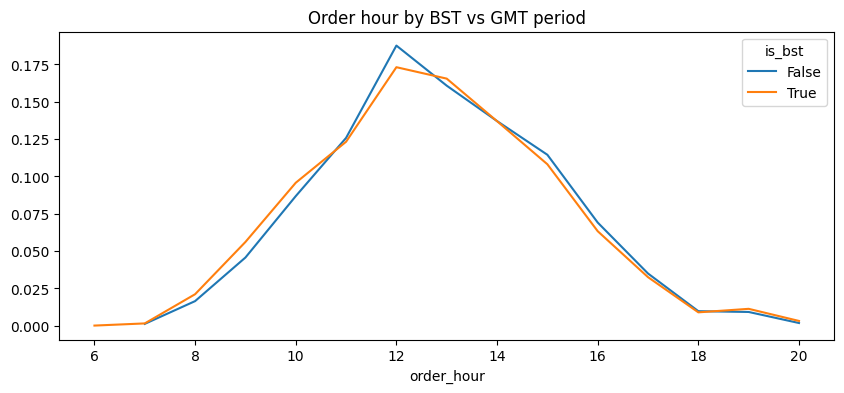

In [5]:
df['month']      = df['InvoiceDateMin'].dt.month
df['is_bst']     = df['month'].between(4, 10)   # rough BST window (Apr-Oct)

# Compare hour distributions for BST vs GMT periods
hour_dist = (df.groupby(['is_bst','order_hour']).size()
               .unstack(level=0)
               .div(df.groupby('is_bst').size()))    # normalise to proportion within each period
hour_dist.plot(kind='line', figsize=(10,4), title='Order hour by BST vs GMT period')

---
We update most common customer country as country_mode

In [5]:
# Most common country per customer (handles ties by taking the first alphabetically)
country_mode = (df.groupby('CustomerHashID')['Country']
                  .agg(lambda x: x.mode().iloc[0])
                  .rename('country_mode'))

customer = customer.drop(columns=['country_mode'], errors='ignore')
customer = customer.merge(country_mode, on='CustomerHashID', how='left')

we check how many customers order from multiple countries. 12

In [6]:
# How many customers ordered from more than one country?
multi_country = df.groupby('CustomerHashID')['Country'].nunique()
print('Customers with >1 country:', (multi_country > 1).sum())
print('Distribution:')
print(multi_country.value_counts().sort_index())

Customers with >1 country: 12
Distribution:
Country
1    5837
2      12
Name: count, dtype: int64


We look at monthly_revenue_trajectory — slope of monthly spend over their activity span (for lifecycle "growing/declining")

In [6]:
import numpy as np
from scipy.stats import linregress
import pandas as pd

# --- Part 1: Define the function ---
def monthly_slope(group):
    # Resample the active window by month-end ('ME') and sum the revenue
    monthly = group.set_index('InvoiceDateMin')['TotalPrice'].resample('ME').sum()
    
    # Rule 1: Must have data spanning at least 3 distinct calendar months
    if len(monthly) < 3:
        return np.nan
        
    # Calculate and return the raw monetary trend (slope)
    return linregress(range(len(monthly)), monthly.values).slope

# --- Part 2: Apply the function ---
# Group transaction data by customer and calculate their slope
slopes = (df.groupby('CustomerHashID')
          .apply(monthly_slope, include_groups=False)
          .rename('rev_slope'))

# --- Part 3: Merge back to customer table ---
# Drop existing columns if re-running, then merge the new slopes in
customer = customer.drop(columns=['rev_slope', 'rev_slope_pct'], errors='ignore')
customer = customer.merge(slopes, on='CustomerHashID', how='left')

# --- Part 4: Apply B2B Time Span Rule ---
# Treat anyone with < 85 days active span as short-term buyer and remove slope
customer.loc[customer['active_span_days'] < 85, 'rev_slope'] = np.nan

# --- Part 5: Percentage Calculation ---
# 1. Prevent division by zero by turning 0 days into NaN
safe_span_days = customer['active_span_days'].replace(0, np.nan)

# 2. Calculate average monthly revenue for active time span
avg_monthly_rev = customer['total_revenue'] / (safe_span_days / 30.44) 

# 3. Calculate percentage slope 
# For rev_slope is NaN for customers with < 85 days or < 3 calendar months,
# default rev_slope_pct to NaN for those customers.
customer['rev_slope_pct'] = customer['rev_slope'] / avg_monthly_rev

In [7]:
# Number of active months — useful for filtering slopes downstream
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

---
We add active_months to assist with diagnosing this type of thing later
- I will look at it when I need it

I just check the distribution

In [9]:
customer['n_active_months'].describe()

count    5849.000000
mean        4.352881
std         4.487245
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: n_active_months, dtype: float64

---
---
# We Look at Firmographic

In [9]:
# Check the country list and count
uniq_country = customer.groupby('country_mode')['country_mode'].value_counts().sort_index()
print(uniq_country)

country_mode
AUSTRALIA                 14
AUSTRIA                   11
BAHRAIN                    2
BELGIUM                   28
BRAZIL                     2
CANADA                     5
CHANNEL ISLANDS           13
CYPRUS                    10
CZECH REPUBLIC             1
DENMARK                    9
EUROPEAN COMMUNITY         1
FINLAND                   13
FRANCE                    93
GERMANY                  106
GREECE                     5
ICELAND                    1
IRELAND                    3
ISRAEL                     4
ITALY                     17
JAPAN                     10
KOREA                      2
LEBANON                    1
LITHUANIA                  1
MALTA                      2
NETHERLANDS               22
NIGERIA                    1
NORWAY                    12
POLAND                     6
PORTUGAL                  22
SAUDI ARABIA               1
SINGAPORE                  1
SOUTH AFRICA               2
SPAIN                     35
SWEDEN                    19
S

---
## We apply the following groupings:
| **country_mode**     | **region**      | **sub_region**            | **count** |
| :------------------- | :-------------- | :------------------------ | :-------- |
| AUSTRALIA            | APAC            | OCEANIA                   | 14        |
| AUSTRIA              | EMEA            | EUROPE / DACH             | 11        |
| BAHRAIN              | EMEA            | MIDDLE EAST               | 2         |
| BELGIUM              | EMEA            | EUROPE / BENELUX          | 28        |
| BRAZIL               | AMER            | AMER / LATAM              | 2         |
| CANADA               | AMER            | AMER / NORAM              | 5         |
| CHANNEL ISLANDS      | CHANNEL ISLANDS | CHANNEL ISLANDS           | 13        |
| CYPRUS               | EMEA            | EUROPE / MEDITERRANEAN    | 10        |
| CZECH REPUBLIC       | EMEA            | EUROPE / CEE              | 1         |
| DENMARK              | EMEA            | EUROPE / NORDICS          | 9         |
| EUROPEAN COMMUNITY   | EMEA            | POLITICAL/REGIONAL ENTITY | 1         |
| FINLAND              | EMEA            | EUROPE / NORDICS          | 13        |
| FRANCE               | EMEA            | EUROPE / CENTRAL          | 93        |
| GERMANY              | EMEA            | EUROPE / DACH             | 106       |
| GREECE               | EMEA            | EUROPE / MEDITERRANEAN    | 5         |
| ICELAND              | EMEA            | EUROPE / NORDICS          | 1         |
| IRELAND              | EMEA            | EUROPE / NORTHERN         | 3         |
| ISRAEL               | EMEA            | MIDDLE EAST               | 4         |
| ITALY                | EMEA            | EUROPE / MEDITERRANEAN    | 17        |
| JAPAN                | APAC            | EAST ASIA                 | 10        |
| KOREA                | APAC            | EAST ASIA                 | 2         |
| LEBANON              | EMEA            | MIDDLE EAST               | 1         |
| LITHUANIA            | EMEA            | EUROPE / BALTICS          | 1         |
| MALTA                | EMEA            | EUROPE / MEDITERRANEAN    | 2         |
| NETHERLANDS          | EMEA            | EUROPE / BENELUX          | 22        |
| NIGERIA              | EMEA            | AFRICA                    | 1         |
| NORWAY               | EMEA            | EUROPE / NORDICS          | 12        |
| POLAND               | EMEA            | EUROPE / CEE              | 6         |
| PORTUGAL             | EMEA            | EUROPE / IBERIA           | 22        |
| SAUDI ARABIA         | EMEA            | MIDDLE EAST               | 1         |
| SINGAPORE            | APAC            | SOUTHEAST ASIA            | 1         |
| SOUTH AFRICA         | EMEA            | AFRICA                    | 2         |
| SPAIN                | EMEA            | EUROPE / IBERIA           | 35        |
| SWEDEN               | EMEA            | EUROPE / NORDICS          | 19        |
| SWITZERLAND          | EMEA            | EUROPE / DACH             | 22        |
| THAILAND             | APAC            | SOUTHEAST ASIA            | 1         |
| UNITED ARAB EMIRATES | EMEA            | MIDDLE EAST               | 4         |
| UNITED KINGDOM       | UK DOMESTIC     | UK DOMESTIC               | 5332      |
| UNITED STATES        | AMER            | AMER / NORAM              | 8         |
| UNSPECIFIED          | UNSPECIFIED     | UNSPECIFIED               | 6         |
| WEST INDIES          | AMER            | AMER / LATAM              | 1         |
| **TOTAL**            | **TOTAL**       | **TOTAL**                 | **5,849** |

In [8]:
# Country — actually present
customer['country_mode']

# Region — derived from country
def country_to_region(c):
    if c == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif c == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif c == 'UNSPECIFIED':
        return 'UNSPECIFIED'
    elif c in ['BRAZIL', 'CANADA', 'UNITED STATES', 'WEST INDIES']:
        return 'AMER'
    elif c in ['AUSTRALIA', 'JAPAN', 'KOREA' ,'SINGAPORE' ,'THAILAND']:
        return 'APAC'
    else:
        return 'EMEA'
    
# Sub-Region — derived from country
def country_to_subregion(cs):
    if cs == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif cs == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif cs == 'IRELAND':
        return 'EUROPE / NORTHERN'
    elif cs in ['BRAZIL', 'WEST INDIES']:
        return 'AMER / LATAM'
    elif cs in ['CANADA', 'UNITED STATES']:
        return 'AMER / NORAM'
    elif cs in ['AUSTRALIA']:
        return 'OCEANIA'
    elif cs == 'EUROPEAN COMMUNITY':
        return 'POLITICAL / REGIONAL ENTITY'
    elif cs in ['AUSTRIA', 'GERMANY', 'SWITZERLAND']:
        return 'EUROPE / DACH'
    elif cs in ['BELGIUM', 'NETHERLANDS']:
        return 'EUROPE / BENELUX'
    elif cs in ['CYPRUS', 'GREECE', 'ITALY', 'MALTA']:
        return 'EUROPE / MEDITERRANEAN'
    elif cs in ['CZECH REPUBLIC', 'POLAND']:
        return 'EUROPE / CEE'
    elif cs in ['DENMARK', 'FINLAND', 'ICELAND', 'NORWAY', 'SWEDEN']:
        return 'EUROPE / NORDICS'
    elif cs in ['FRANCE']:
        return 'EUROPE / CENTRAL'
    elif cs in ['LITHUANIA']:
        return 'EUROPE / BALTICS'
    elif cs in ['PORTUGAL', 'SPAIN']:
        return 'EUROPE / IBERIA'
    elif cs in ['BAHRAIN', 'ISRAEL', 'LEBANON', 'SAUDI ARABIA', 'UNITED ARAB EMIRATES']:
        return 'MIDDLE EAST'
    elif cs in ['JAPAN', 'KOREA']:
        return 'EAST ASIA'
    elif cs in ['SINGAPORE' ,'THAILAND']:
        return 'SOUTHEAST ASIA'
    elif cs in ['NIGERIA', 'SOUTH AFRICA']:
        return 'AFRICA'
    else:
        return 'UNSPECIFIED'

customer['region'] = customer['country_mode'].apply(country_to_region)
customer['sub_region'] = customer['country_mode'].apply(country_to_subregion)

# naming convention change KOREA to SOUTH KOREA
customer['country_mode'] = customer['country_mode'].replace('KOREA', 'SOUTH KOREA')

In [11]:
# Check the region list and count
# Option 3 — as a tidy DataFrame with a named count column (nicest for further use)
uniq_region = (customer.groupby(['region','sub_region'])
                       .size()
                       .reset_index(name='n_customers')
                       .sort_values(['region','sub_region']))
print(uniq_region)

             region                   sub_region  n_customers
0              AMER                 AMER / LATAM            3
1              AMER                 AMER / NORAM           13
2              APAC                    EAST ASIA           12
3              APAC                      OCEANIA           14
4              APAC               SOUTHEAST ASIA            2
5   CHANNEL ISLANDS              CHANNEL ISLANDS           13
6              EMEA                       AFRICA            3
7              EMEA             EUROPE / BALTICS            1
8              EMEA             EUROPE / BENELUX           50
9              EMEA                 EUROPE / CEE            7
10             EMEA             EUROPE / CENTRAL           93
11             EMEA                EUROPE / DACH          139
12             EMEA              EUROPE / IBERIA           57
13             EMEA       EUROPE / MEDITERRANEAN           34
14             EMEA             EUROPE / NORDICS           54
15      

---
---
# RFM and Seasonality

In [9]:
import pandas as pd
import numpy as np

# RECENCY — lower days = better, so labels run 5→1 (most recent gets 5)
customer['R'] = pd.qcut(customer['recency_days'],
                        q=5,
                        labels=[5, 4, 3, 2, 1],
                        duplicates='drop').astype(int)

# FREQUENCY — many customers have n_invoices = 1, 2, 3, which causes qcut
# to fail on duplicate quantile edges. Rank-then-qcut breaks ties cleanly.
customer['F'] = pd.qcut(customer['n_invoices'].rank(method='first'),
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# MONETARY — higher revenue = better
customer['M'] = pd.qcut(customer['total_revenue'],
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# Combined score for sorting/sanity-checking
customer['RFM_score'] = customer[['R','F','M']].sum(axis=1)
customer['RFM_cell'] = (customer['R'].astype(str) +
                        customer['F'].astype(str) +
                        customer['M'].astype(str))

In [13]:
# Each bucket should contain ~20% of customers
customer[['R','F','M']].apply(lambda c: c.value_counts(normalize=True).sort_index())

,R,F,M
1,0.198837,0.200034,0.200205
2,0.200376,0.200034,0.199863
3,0.197470,0.199863,0.199863
4,0.200889,0.200034,0.200034
5,0.202428,0.200034,0.200034


count    5849.000000
mean        9.007523
std         3.643756
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64


<Axes: >

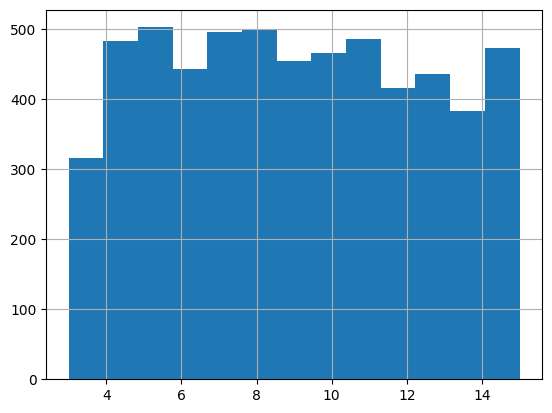

In [19]:
# Top 10 most populated RFM cells — shows where your customer base concentrates
# print(customer['RFM_cell'].value_counts().head(10))

# RFM_score distribution — should look roughly normal-ish, peaked around 9
print(customer['RFM_score'].describe())
customer['RFM_score'].hist(bins=13)

In [21]:
# Quick check to confirm the corners are dense
print(customer['RFM_cell'].value_counts().head(5))
# (1,1,1) and (5,5,5) should both feature prominently

RFM_cell
555    473
111    316
455    253
121    170
211    169
Name: count, dtype: int64


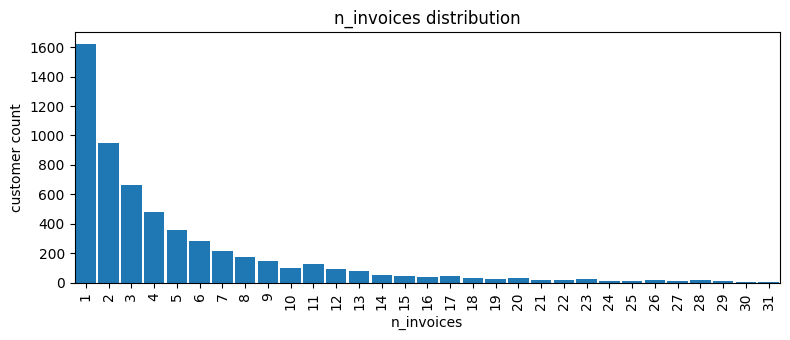

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))

customer['n_invoices'].value_counts().sort_index().plot.bar(width=0.9)
plt.title('n_invoices distribution')
plt.xlabel('n_invoices')
plt.ylabel('customer count')
plt.xlim(-0.5, 30.5)   # zoom to the dense part

plt.tight_layout(); plt.show()

In [23]:
for col in ['R','F','M']:
    print(f'{col} bucket sizes:')
    print(customer[col].value_counts().sort_index())
    print()

R bucket sizes:
R
1    1163
2    1172
3    1155
4    1175
5    1184
Name: count, dtype: int64

F bucket sizes:
F
1    1170
2    1170
3    1169
4    1170
5    1170
Name: count, dtype: int64

M bucket sizes:
M
1    1171
2    1169
3    1169
4    1170
5    1170
Name: count, dtype: int64



In [24]:
print('Recency (days since last purchase) by R bucket:')
print(customer.groupby('R')['recency_days'].agg(['min','max','count']))

print('\nFrequency (n_invoices) by F bucket:')
print(customer.groupby('F')['n_invoices'].agg(['min','max','count']))

print('\nMonetary (total_revenue) by M bucket:')
print(customer.groupby('M')['total_revenue'].agg(['min','max','count']))

Recency (days since last purchase) by R bucket:
   min  max  count
R                 
1  409  737   1163
2  187  408   1172
3   59  186   1155
4   19   58   1175
5    0   18   1184

Frequency (n_invoices) by F bucket:
   min  max  count
F                 
1    1    1   1170
2    1    2   1170
3    2    4   1169
4    4    8   1170
5    8  370   1170

Monetary (total_revenue) by M bucket:
       min        max  count
M                           
1     2.90     288.10   1171
2   288.42     612.78   1169
3   612.94    1227.54   1169
4  1229.95    2940.36   1170
5  2942.31  607539.25   1170


In [25]:
customer.loc[customer['F']==5, 'n_invoices'].describe()
customer.loc[customer['F']==5, 'n_invoices'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     13.00
0.75     20.00
0.90     33.00
0.95     45.00
0.99    122.55
Name: n_invoices, dtype: float64

---
### Now we apply lifecycle labels

In [10]:
def lifecycle_label(row):
    r, f, m = row['R'], row['F'], row['M']

    # Top-tier High-Value engaged
    if r >= 4 and f >= 4 and m >= 4:        return 'Champions'
    if r == 3 and f >= 4 and m >= 4:        return 'Loyal'
    if r <= 2 and f >= 4 and m >= 4:        return 'Cannot Lose Them'

    # Top-tier engaged
    if r >= 4 and f >= 4 and m == 3:        return 'Champions Lower-Value'
    if r == 3 and f >= 4 and m == 3:        return 'Loyal Lower-Value'
    if r <= 2 and f >= 4 and m <= 3:        return 'Cannot Lose Lower-Value'

    # New / acquisition phase
    if r >= 4 and f <= 2:                   return 'New / Promising'

    # Mid-tier engaged
    if r >= 3 and f >= 3 and m <= 2:        return 'Frequent Low-Spend'
    if r >= 3 and f == 3 and m >= 3:        return 'About to Sleep'

    # Mid-recency drift
    if r == 3 and f <= 2:                   return 'Needs Attention'

    # Lapsing / lapsed
    if r <= 2 and f == 3:                   return 'At Risk'
    if r <= 2 and f <= 2 and m >= 4:        return 'Lost High-Value'
    if r <= 2 and f <= 2 and m <= 3:        return 'Hibernating / Lost'
    
    # Catch-all: should be empty.
    return 'UNCLASSIFIED'

customer['lifecycle_segment'] = customer.apply(lifecycle_label, axis=1)

# Sanity check the distribution
print(customer['lifecycle_segment'].value_counts())

lifecycle_segment
Hibernating / Lost         1451
Champions                  1301
About to Sleep              486
At Risk                     466
New / Promising             451
Loyal                       398
Needs Attention             373
Frequent Low-Spend          265
Cannot Lose Them            237
Champions Lower-Value       160
Cannot Lose Lower-Value     116
Loyal Lower-Value            80
Lost High-Value              65
Name: count, dtype: int64


In [11]:
# 1. Filter the dataframe to ONLY the unclassified customers
unclassified = customer[customer['lifecycle_segment'] == 'UNCLASSIFIED'].copy()

# 2. Combine the R, F, and M columns into a single string (e.g., R=2, F=2, M=3 becomes '223')
unclassified['RFM_pattern'] = (
    unclassified['R'].astype(str) + 
    unclassified['F'].astype(str) + 
    unclassified['M'].astype(str)
)

# 3. Print the counts of these missing patterns
print("Missing RFM Combinations (R-F-M):")
print(unclassified['RFM_pattern'].value_counts())

Missing RFM Combinations (R-F-M):
Series([], Name: count, dtype: int64)


Champions and Hibernating are about 22% each. We can check hibernating versus seaonaility later, lets look at grapphs

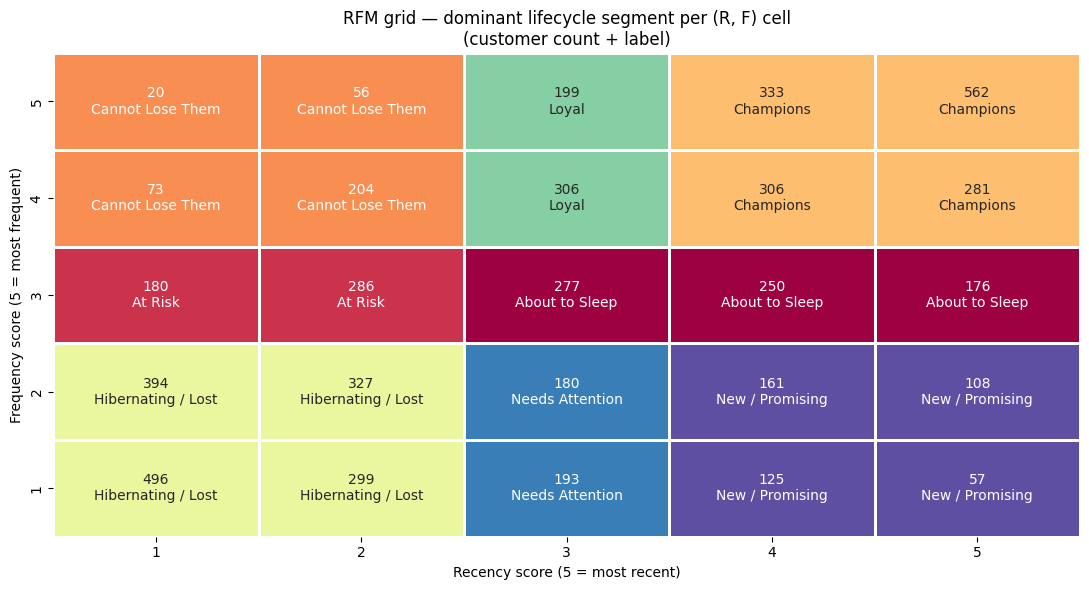

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build the label→int map
labels_unique = sorted(customer['lifecycle_segment'].dropna().unique())
label_to_int  = {lbl: i for i, lbl in enumerate(labels_unique)}
int_to_label  = {i: lbl for lbl, i in label_to_int.items()}

# Add an integer code column on customer, then groupby it directly — avoids dtype issues
customer['_lifecycle_code'] = customer['lifecycle_segment'].map(label_to_int)

# For each (R, F) cell, take the modal code
grid_numeric = (customer.groupby(['F','R'])['_lifecycle_code']
                        .agg(lambda x: x.mode().iloc[0])
                        .unstack('R')
                        .astype(float))

# Customer counts per cell
counts = (customer.groupby(['F','R']).size()
                  .unstack('R').fillna(0).astype(int))

# Build annotation: "count\nlabel" for populated cells, '' for empty
annot = pd.DataFrame('', index=grid_numeric.index, columns=grid_numeric.columns)
for r in grid_numeric.index:
    for c in grid_numeric.columns:
        v = grid_numeric.loc[r, c]
        if pd.notna(v):
            annot.loc[r, c] = f"{counts.loc[r, c]:,}\n{int_to_label[int(v)]}"

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(grid_numeric.iloc[::-1],         # flip so F=5 sits at the top
            annot=annot.iloc[::-1],
            fmt='',
            cmap='Spectral',
            cbar=False,
            linewidths=1,
            linecolor='white',
            ax=ax)
ax.set_title('RFM grid — dominant lifecycle segment per (R, F) cell\n(customer count + label)')
ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
plt.tight_layout()
plt.show()

# Tidy up
customer = customer.drop(columns='_lifecycle_code')

In [29]:
print(grid_numeric.dtypes)
print(grid_numeric)

R
1    float64
2    float64
3    float64
4    float64
5    float64
dtype: object
R    1    2     3     4     5
F                            
1  7.0  7.0  11.0  12.0  12.0
2  7.0  7.0  11.0  12.0  12.0
3  1.0  1.0   0.0   0.0   0.0
4  3.0  3.0   9.0   4.0   4.0
5  3.0  3.0   9.0   4.0   4.0


In [ ]:
# !pip install squarify

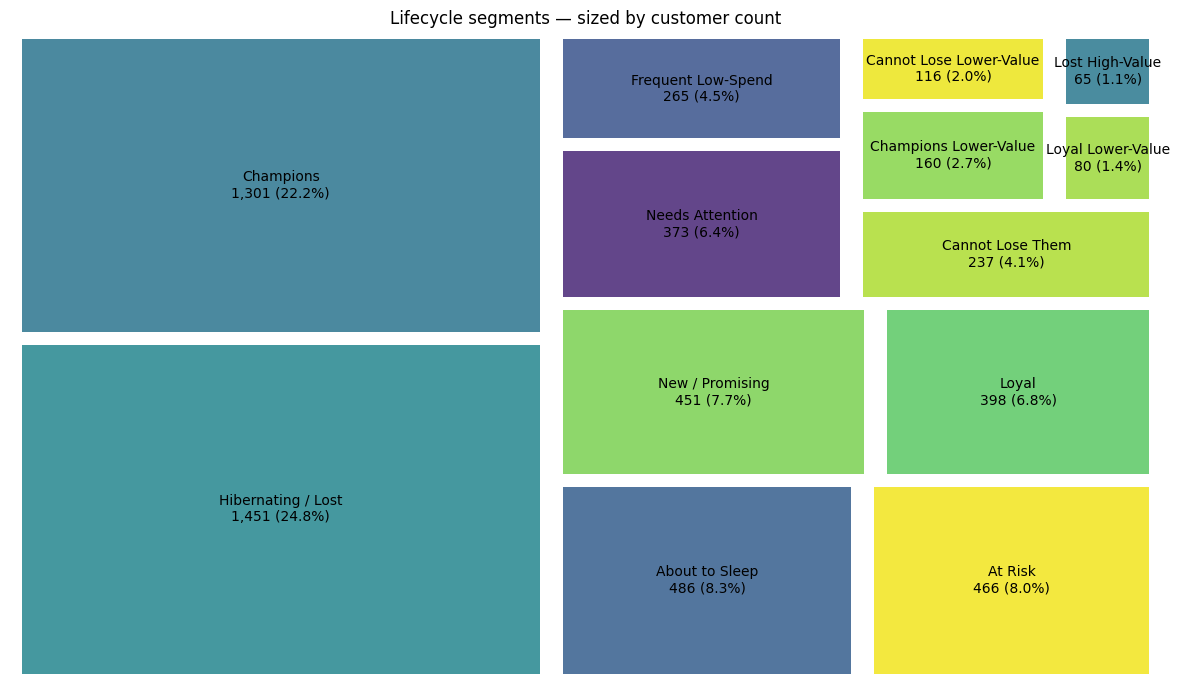

In [30]:
import squarify
import matplotlib.pyplot as plt

seg_counts = customer['lifecycle_segment'].value_counts()
labels = [f'{name}\n{count:,} ({count/len(customer)*100:.1f}%)'
          for name, count in seg_counts.items()]

plt.figure(figsize=(12, 7))
squarify.plot(sizes=seg_counts.values,
              label=labels,
              alpha=0.85,
              pad=True,
              text_kwargs={'fontsize': 10, 'wrap': True})
plt.title('Lifecycle segments — sized by customer count')
plt.axis('off')
plt.tight_layout()
plt.show()

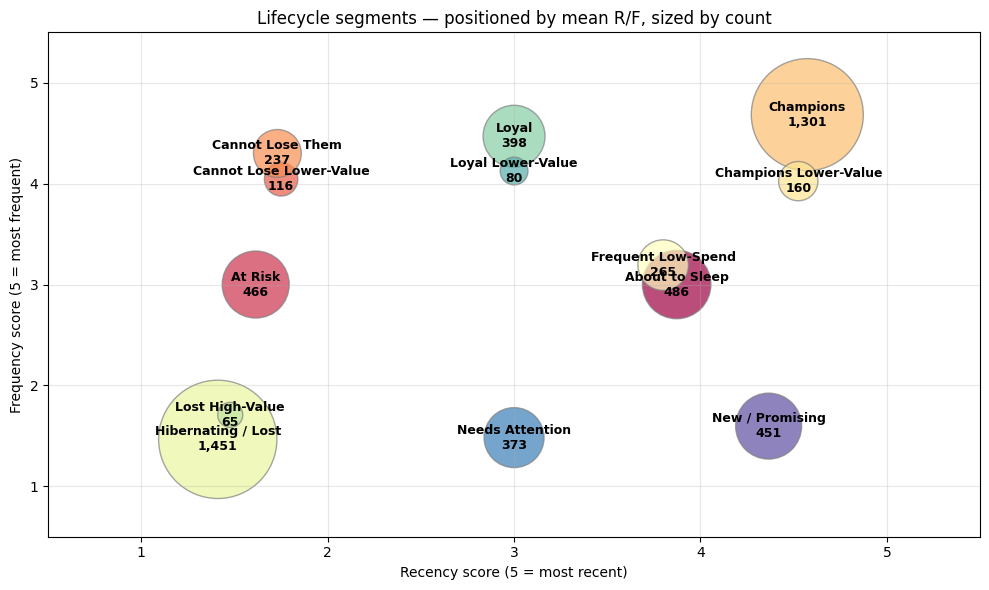

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Compute centroid (R,F) for each segment, weighted by count, plus segment size
seg_summary = (customer.groupby('lifecycle_segment')
                       .agg(R_mean=('R','mean'),
                            F_mean=('F','mean'),
                            count=('CustomerHashID','count'))
                       .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(seg_summary['R_mean'],
                     seg_summary['F_mean'],
                     s=seg_summary['count'] * 5,    # bubble size
                     c=range(len(seg_summary)),
                     cmap='Spectral',
                     alpha=0.7,
                     edgecolors='grey',
                     linewidth=1)

# Label each bubble with segment name and count
for _, row in seg_summary.iterrows():
    ax.annotate(f"{row['lifecycle_segment']}\n{row['count']:,}",
                (row['R_mean'], row['F_mean']),
                ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
ax.set_title('Lifecycle segments — positioned by mean R/F, sized by count')
ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6)); ax.set_yticks(range(1, 6))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

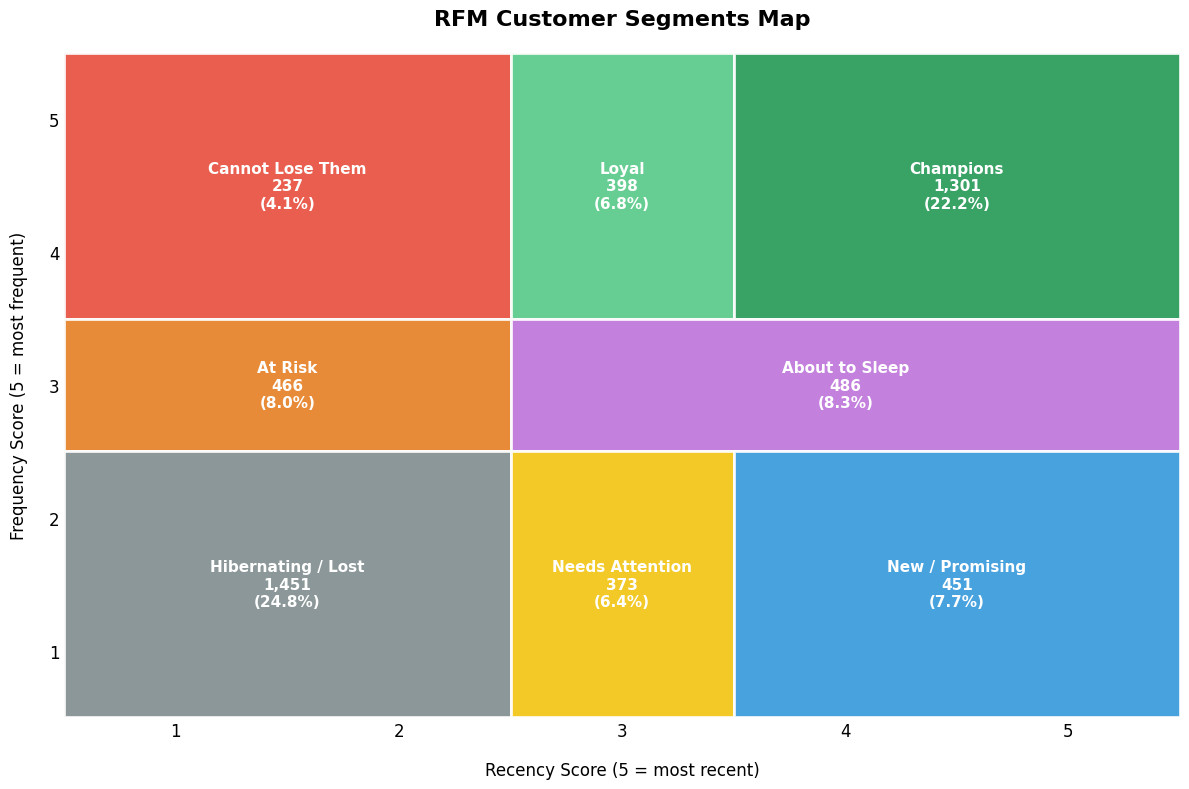

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Get customer counts and percentages (same as your previous code)
seg_counts = customer['lifecycle_segment'].value_counts()
total_customers = len(customer)

# 2. Use your exact custom color map
colour_map = {
    'Champions':           "#239854",
    'Loyal':               "#55c986",
    'Cannot Lose Them':         '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 '#bd72da',
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. Define the fixed coordinates for each segment on a 5x5 grid.
# Format: 'Segment Name': (x_start, y_start, width, height)
# x = Recency (0 to 5), y = Frequency (0 to 5)
segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),  # R:1-2, F:4-5
    'Loyal':         (2, 3, 1, 2),  # R:3,   F:4-5
    'Champions':     (3, 3, 2, 2),  # R:4-5, F:4-5
    
    'At Risk':                  (0, 2, 2, 1),  # R:1-2, F:3
    'About to Sleep':           (2, 2, 3, 1),  # R:3-5, F:3
    
    'Hibernating / Lost':       (0, 0, 2, 2),  # R:1-2, F:1-2
    'Needs Attention':          (2, 0, 1, 2),  # R:3,   F:1-2
    'New / Promising':          (3, 0, 2, 2),  # R:4-5, F:1-2
}

# Create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Loop through the boxes, draw them, and add the text
for seg, (x, y, w, h) in segment_boxes.items():
    
    # Get the count and calc percentage (handle missing segments gracefully)
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    label_text = f"{seg}\n{count:,}\n({pct:.1f}%)"
    
    # Draw the rectangle
    rect = patches.Rectangle(
        (x, y), w, h, 
        linewidth=2, 
        edgecolor='white', # Creates the gap/border between boxes
        facecolor=colour_map.get(seg, '#333333'), 
        alpha=0.9
    )
    ax.add_patch(rect)
    
    # Add the text in the center of the rectangle
    ax.text(
        x + w/2, y + h/2, 
        label_text, 
        ha='center', va='center', 
        color='white', fontsize=11, fontweight='bold',
        wrap=True
    )

# 5. Format the axes to look like an RFM grid
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Set ticks to be in the middle of the blocks (0.5, 1.5, 2.5, etc.)
ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])

# Label the ticks 1 to 5
ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=12)
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=12)

ax.set_xlabel('Recency Score (5 = most recent)', fontsize=12, labelpad=15)
ax.set_ylabel('Frequency Score (5 = most frequent)', fontsize=12, labelpad=15)
ax.set_title('RFM Customer Segments Map', fontsize=16, fontweight='bold', pad=20)

# Remove the outer spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks (keep the labels)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

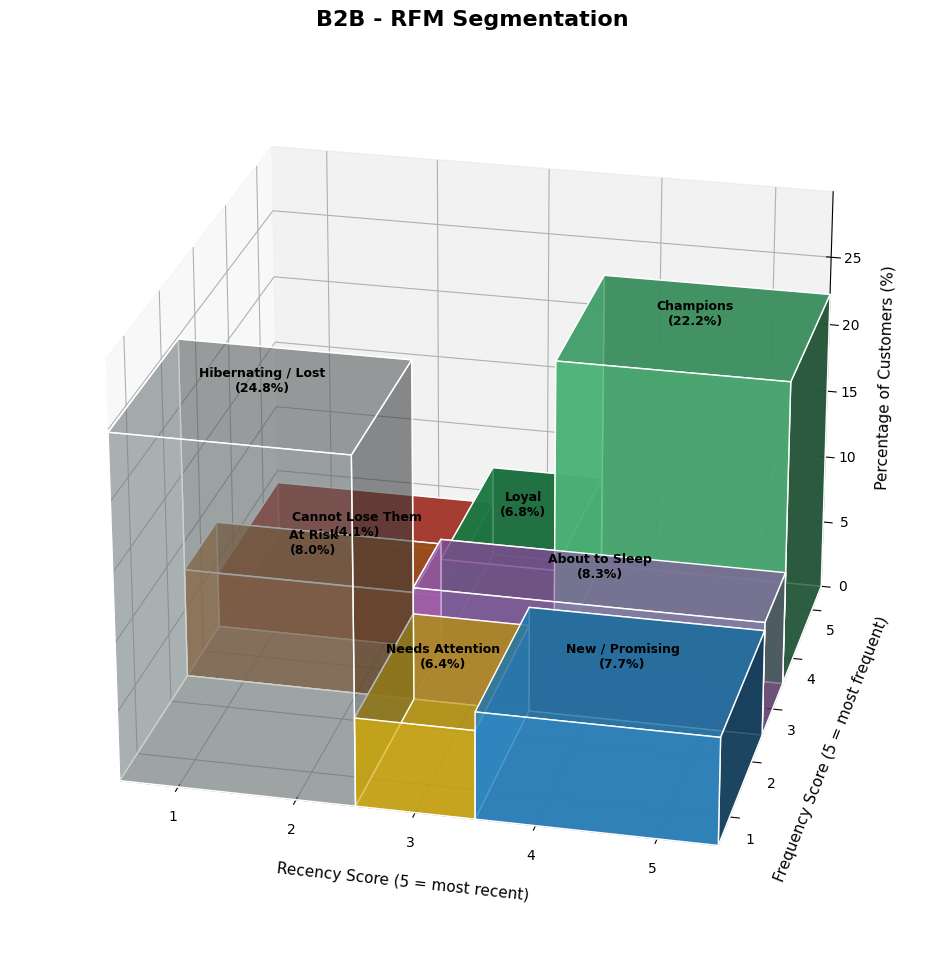

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup counts and total
seg_counts = customer['lifecycle_seg*sment'].value_counts()
total_customers = len(customer)

# 2. Colour Map (Base Colors)
colour_map = {
    'Champions':                      '#55c986',
    'Loyal':                          '#239854',
    'Cannot Lose Them':               '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 "#bd72da",
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. NEW: Alpha (Transparency) Map
# 1.0 is completely solid, 0.0 is invisible.
# We make the tall blocks in the front transparent, and the short blocks in the back solid.
alpha_map = {
    'Hibernating / Lost':        0.35, # Very transparent
    'At Risk':                   0.50, # Semi-transparent
    'About to Sleep':            0.60, 
    'Needs Attention':           0.70, 
    'New / Promising':           0.85, # Mostly solid 
    'Loyal High-Value':          0.85, 
    'Champions High-Value':      0.95, 
    'Cannot Lose High-Value':    1.0,  # Opaque
}

# Fixed Grid Coordinates: 'Segment': (x_start, y_start, width, depth)
segment_boxes = {
    'Cannot Lose Them':          (0, 3, 2, 2),  
    'Loyal':                     (2, 3, 1, 2),  
    'Champions':                 (3, 3, 2, 2),  
    'At Risk':                   (0, 2, 2, 1),  
    'About to Sleep':            (2, 2, 3, 1),  
    'Hibernating / Lost':        (0, 0, 2, 2),  
    'Needs Attention':           (2, 0, 1, 2),  
    'New / Promising':           (3, 0, 2, 2),  
}

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = [], [], []
dx, dy, dz = [], [], []
colors = []
max_pct = 0

# 4. Build the 3D data arrays
for seg, (x, y, w, h) in segment_boxes.items():
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    if pct > max_pct: max_pct = pct

    x_pos.append(x)
    y_pos.append(y)
    z_pos.append(0) 
    
    dx.append(w)
    dy.append(h)
    dz.append(pct)
    
    # --- NEW COLOR LOGIC ---
    base_color = colour_map.get(seg, '#333333')
    alpha_val = alpha_map.get(seg, 0.8) # Default to 0.8 if not in the alpha map
    
    # Convert hex to RGBA using Matplotlib's to_rgba
    rgba_color = mcolors.to_rgba(base_color, alpha_val)
    colors.append(rgba_color)
    # -----------------------

    # Add text floating slightly above the block
    label_text = f"{seg}\n({pct:.1f}%)"
    
    # make text more readable
    text_z = pct + 1.0 
    
    ax.text(
        x + (w / 2), y + (h / 2), text_z, 
        label_text, 
        ha='center', va='center', 
        fontsize=9, fontweight='bold', color='black'
    )

# 5. Draw the 3D blocks
ax.bar3d(
    x_pos, y_pos, z_pos, 
    dx, dy, dz, 
    color=colors,         # Using custom RGBA list
    edgecolor='white',  
    shade=True            
    # REMOVED alpha=0.9 from here!
)

# Formatting the Axes
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
z_limit = max(25, max_pct + 5) 
ax.set_zlim(0, z_limit)

ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticklabels(['1', '2', '3', '4', '5'])

ax.set_xlabel('\nRecency Score (5 = most recent)', fontsize=11, linespacing=3)
ax.set_ylabel('\nFrequency Score (5 = most frequent)', fontsize=11, linespacing=3)
ax.set_zlabel('Percentage of Customers (%)', fontsize=11, labelpad=10)

plt.title('B2B - Lifecycle Segmentation of 5,849 Customers', fontsize=16, fontweight='bold', pad=0)

ax.view_init(elev=24, azim=-77) 
plt.show()

##### Now the above is starting to look like what I want. I need to format it better (like the text) but it becomes obvious to see the groups and their size.
I need to change the colours

Okay I still need to do seasonality and the slice and dice to understand Champion persona since 22% Champion and 22% Hibernting / Lost is a different lense depending on persona.

---
### We look at the share of revenue defined as tier_value
Key accounts (expected 20% or so of accounts for 80% or so of revenue), Mid and long tail

In [12]:
import numpy as np

# Sort and calculate Pareto distribution
# We sort by total revenue full span
customer = customer.sort_values('total_revenue', ascending=False).reset_index(drop=True)

# Calculate the cumulative percentage full span
customer['hist_cum_rev_pct'] = (
    customer['total_revenue'].cumsum() / 
    customer['total_revenue'].sum()
)

def hist_value_tier(pct):
    if pct <= 0.80:  return 'Key Account'     # Top 80% 
    if pct <= 0.95:  return 'Core Account'    # Next 15% 
    return 'Standard Account'                 # Bottom 5%    

customer['historical_value_tier'] = customer['hist_cum_rev_pct'].apply(hist_value_tier)

print(customer['historical_value_tier'].value_counts())

historical_value_tier
Standard Account    2586
Core Account        1888
Key Account         1375
Name: count, dtype: int64


In [13]:
import numpy as np

# Sort and calculate Pareto distribution
# We sort by new metric so that Key Accounts represent LTT
customer = customer.sort_values('ltm_revenue', ascending=False).reset_index(drop=True)

# Calculate the cumulative percentage LTT
customer['curr_cum_rev_pct'] = (
    customer['ltm_revenue'].cumsum() / 
    customer['ltm_revenue'].sum()
)

def curr_value_tier(pct):
    if pct <= 0.80:  return 'Key Account'     # Top 80% 
    if pct <= 0.95:  return 'Core Account'    # Next 15% 
    return 'Standard Account'                 # Bottom 5%    

customer['current_value_tier'] = customer['curr_cum_rev_pct'].apply(curr_value_tier)

print(customer['current_value_tier'].value_counts())

current_value_tier
Standard Account    3250
Core Account        1436
Key Account         1163
Name: count, dtype: int64


In [16]:
# Ghost Whales (Used to be Key, now Standard)
ghosts = customer[(customer['historical_value_tier'] == 'Key Account') & 
                  (customer['current_value_tier'] == 'Standard Account')]

# Hidden Gems / High-Velocity Newbies (Used to be Standard, now Key)
rising_stars = customer[(customer['historical_value_tier'] == 'Standard Account') & 
                        (customer['current_value_tier'] == 'Key Account')]

display(ghosts)

,CustomerHashID,n_invoices,n_lines,n_skus,total_qty,total_revenue,ttm_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,...,R,F,M,RFM_score,RFM_cell,lifecycle_segment,hist_cum_rev_pct,historical_value_tier,curr_cum_rev_pct,current_value_tier
2606,b3e335b9eb011eede63f373cf54a2f3215801d33f45a9b...,9,131,114,1762,3037.61,458.57,13.450382,12.0,60,...,4,5,5,14,455,Champions,0.761985,Key Account,0.950433,Standard Account
2615,f2deb7db08c829f62e584c04850b6f78d88a72250ba704...,11,157,130,1797,3015.22,454.24,11.445860,12.0,48,...,2,5,5,12,255,Cannot Lose Them,0.762694,Key Account,0.950935,Standard Account
2630,0a9d537c12b4ab484c53a34e4dce19bd212c227fbe79d6...,32,675,516,3094,4728.25,449.29,4.583704,2.0,96,...,3,5,5,13,355,Loyal,0.661176,Key Account,0.951763,Standard Account
2707,fdc1b3df759e763d04589db2da6172654e7ae385dd6e58...,12,496,316,1202,3031.90,418.83,2.423387,2.0,20,...,4,5,5,14,455,Champions,0.762340,Key Account,0.955830,Standard Account
2711,3e9c16ce88b8fd21a5793b670e0b4e894377d6a84d6264...,8,367,259,2910,6272.53,417.69,7.929155,6.0,40,...,2,4,5,11,245,Cannot Lose Them,0.600748,Key Account,0.956035,Standard Account
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4907,315c2a3b0d6f75a7f9821c1e3465531f9809f47074ce24...,1,45,45,1460,2622.48,0.00,32.444444,24.0,200,...,1,1,4,6,114,Lost High-Value,0.787039,Key Account,1.000000,Standard Account
4929,4260c99719c6c11eb7d4a3fafaf2301cee6920e6398c56...,5,163,126,1394,2502.82,0.00,8.552147,6.0,50,...,2,4,4,10,244,Cannot Lose Them,0.795322,Key Account,1.000000,Standard Account
4936,cbac6b035b8835b2a2bfe86817bd6572ff2404339bfbd5...,7,142,103,1477,2542.79,0.00,10.401408,8.0,36,...,1,4,4,9,144,Cannot Lose Them,0.793843,Key Account,1.000000,Standard Account
4939,e67623e0d980329724904c52e53afdeb8756ca63449033...,2,64,56,2084,2558.96,0.00,32.562500,18.0,504,...,1,3,4,8,134,At Risk,0.792348,Key Account,1.000000,Standard Account


#### Let's check the distributions so I can test last 12 month revenue versus total revenue

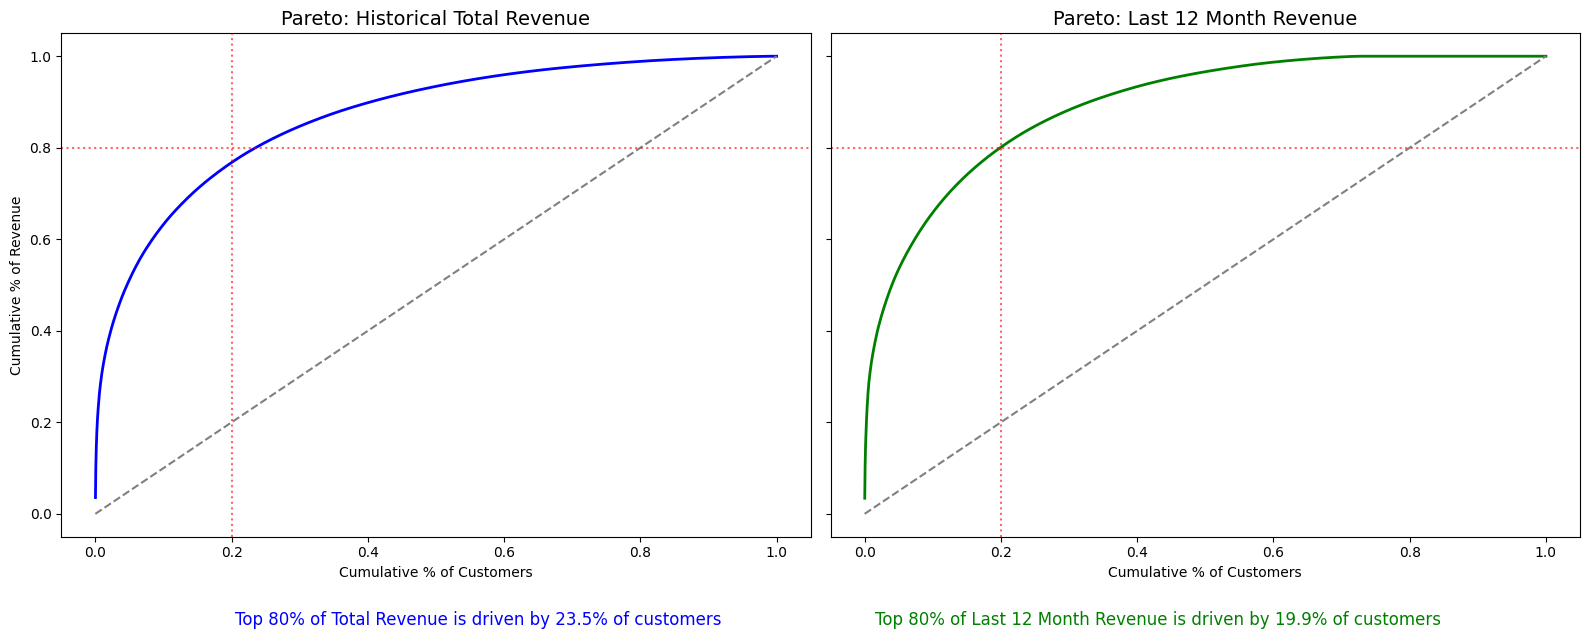

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data for Total Revenue
df_tot = customer.sort_values('total_revenue', ascending=False).reset_index(drop=True)
df_tot['cum_rev_pct'] = df_tot['total_revenue'].cumsum() / df_tot['total_revenue'].sum()
df_tot['cum_cust_pct'] = (df_tot.index + 1) / len(df_tot)

# 2. Prepare data for Last 12 month Revenue
df_ann = customer.sort_values('ttm_revenue', ascending=False).reset_index(drop=True)
df_ann['cum_rev_pct'] = df_ann['ttm_revenue'].cumsum() / df_ann['ttm_revenue'].sum()
df_ann['cum_cust_pct'] = (df_ann.index + 1) / len(df_ann)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot A: Total Revenue
axes[0].plot(df_tot['cum_cust_pct'], df_tot['cum_rev_pct'], color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--') # Line of absolute equality
axes[0].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[0].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[0].set_title('Pareto: Historical Total Revenue', fontsize=14)
axes[0].set_xlabel('Cumulative % of Customers')
axes[0].set_ylabel('Cumulative % of Revenue')

# Plot B: Normalised Revenue
axes[1].plot(df_ann['cum_cust_pct'], df_ann['cum_rev_pct'], color='green', lw=2)
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].axhline(0.80, color='red', linestyle=':', alpha=0.6)
axes[1].axvline(0.20, color='red', linestyle=':', alpha=0.6)
axes[1].set_title('Pareto: Last 12 Month Revenue', fontsize=14)
axes[1].set_xlabel('Cumulative % of Customers')

# Calculate exactly how many customers make up the top 80% for both
top_80_tot = df_tot[df_tot['cum_rev_pct'] <= 0.80].shape[0] / len(df_tot)
top_80_ann = df_ann[df_ann['cum_rev_pct'] <= 0.80].shape[0] / len(df_ann)

plt.figtext(0.15, -0.05, f"Top 80% of Total Revenue is driven by {top_80_tot*100:.1f}% of customers", fontsize=12, color='blue')
plt.figtext(0.55, -0.05, f"Top 80% of Last 12 Month Revenue is driven by {top_80_ann*100:.1f}% of customers", fontsize=12, color='green')

plt.tight_layout()
plt.show()

In [17]:
# Who is in the Top 80%?
tot_key_accounts = set(df_tot[df_tot['cum_rev_pct'] <= 0.80]['CustomerHashID'])
ann_key_accounts = set(df_ann[df_ann['cum_rev_pct'] <= 0.80]['CustomerHashID'])

# Calculate the difference
dropped_out = len(tot_key_accounts - ann_key_accounts)
newly_promoted = len(ann_key_accounts - tot_key_accounts)

print(f"By addressing >1 year historical bias, {dropped_out} legacy customers are moved out of the Key Account tier.")
print(f"They were replaced by {newly_promoted} active customers who are driving current value.")

By addressing >1 year historical bias, 372 legacy customers are moved out of the Key Account tier.
They were replaced by 160 active customers who are driving current value.


---
### Look at Trajectory using rev_slope_pct + n_active_months

In [14]:
# Define "trustworthy" slope: at least 3 active months
trustworthy = customer['n_active_months'] >= 3

# Tercile the trustworthy slopes — top 1/3 = Growing, bottom 1/3 = Declining
upper_cut = customer.loc[trustworthy, 'rev_slope_pct'].quantile(0.66)
lower_cut = customer.loc[trustworthy, 'rev_slope_pct'].quantile(0.33)

def trajectory_label(row):
    if row['n_active_months'] < 3 or pd.isna(row['rev_slope_pct']):
    # if pd.isna(row['rev_slope_pct']):
        return 'Insufficient data'
    if row['rev_slope_pct'] >= upper_cut: return 'Growing'
    if row['rev_slope_pct'] <= lower_cut: return 'Declining'
    return 'Stable'

customer['trajectory'] = customer.apply(trajectory_label, axis=1)

print(customer['trajectory'].value_counts())
print(f"Growing threshold: {upper_cut:.3f} ({upper_cut*100:.1f}% per month)")
print(f"Declining threshold: {lower_cut:.3f} ({lower_cut*100:.1f}% per month)")

trajectory
Insufficient data    2927
Growing               994
Stable                964
Declining             964
Name: count, dtype: int64
Growing threshold: 0.013 (1.3% per month)
Declining threshold: -0.044 (-4.4% per month)


---
### Let's check lifecycle_segment, value_tier and trajectory

In [19]:
# 1 Are Cannot Lose Them customers actually high-value? They should be.
# pd.crosstab(customer['lifecycle_segment'], customer['value_tier'])

# 2 Are Champions usually Growing or Stable? Mostly yes? — declining champions are rare.
pd.crosstab(customer['lifecycle_segment'], customer['trajectory'])

# 3 The three-way matrix of populated personas. Note this is the first draft
# I still need seasonality, k-means on behviour, product affinity but this is a starting point for refining
# pd.crosstab([customer['lifecycle_segment'], customer['value_tier']], customer['trajectory'])

trajectory,Declining,Growing,Insufficient data,Stable
lifecycle_segment,,,,
About to Sleep,134,114,153,85
At Risk,89,102,238,37
Cannot Lose Lower-Value,45,36,18,17
Cannot Lose Them,109,62,11,55
Champions,290,451,31,529
Champions Lower-Value,50,60,12,38
Frequent Low-Spend,60,46,120,39
Hibernating / Lost,0,0,1451,0
Lost High-Value,0,0,65,0


#### For 2 above we see significant declining champions, I need to check:
Looking at the split below, this is fine.  73% stable or growing seems about right with 23% in decline

In [20]:
champ = customer[customer['lifecycle_segment']=='Champions']
print(champ['trajectory'].value_counts(normalize=True))

trajectory
Stable               0.406610
Growing              0.346656
Declining            0.222905
Insufficient data    0.023828
Name: proportion, dtype: float64


In [27]:
declining_champs = customer[(customer['lifecycle_segment']=='Champions') & 
                            (customer['trajectory']=='Declining')]
print(declining_champs[['total_revenue', 'n_invoices', 'recency_days', 
                        'rev_slope', 'rev_slope_pct', 'n_active_months']].describe())

       total_revenue  n_invoices  recency_days   rev_slope  rev_slope_pct  \
count     290.000000  290.000000    290.000000  290.000000     290.000000   
mean     5371.121069   12.703448     22.196552  -36.521951      -0.100353   
std     12280.993389   14.178850     16.770773   63.759643       0.077839   
min      1258.970000    4.000000      0.000000 -502.773769      -0.725444   
25%      1995.532500    6.250000      8.000000  -30.755235      -0.114636   
50%      3013.720000    9.000000     20.000000  -17.756933      -0.074493   
75%      5170.912500   13.000000     35.000000   -9.746498      -0.055307   
max    194595.010000  140.000000     58.000000   -2.724608      -0.044049   

       n_active_months  
count       290.000000  
mean          8.379310  
std           4.269582  
min           3.000000  
25%           5.000000  
50%           7.000000  
75%          10.000000  
max          25.000000  


here we can confirm mean revenue £5,202, 12 or so invoices, mild -£50 revenue slope these are declining in the top tier but not falling out
---
Let's check a few:

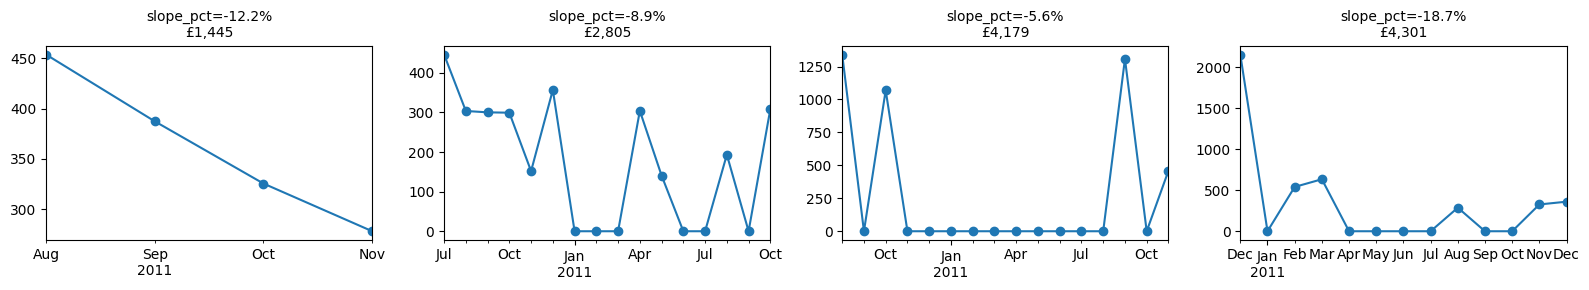

In [48]:
import matplotlib.pyplot as plt

# Pull 4 random declining Champions and plot their monthly trajectories
sample = declining_champs.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

**Okay there are a few things going on above from left 1 to right 4**
- 1 does look like a lower spend champion who we need to look after, outreach recommended
- 2 this looks a bit erratic, they seem to order in bursts, there might be some seasonality in here with oct - dec winter with what looks like the beginning of a repeat next oct and a mar to may spring-time, looks fine
- 3 this has an oct to oct pattern like yearly purchase, we would leave alone
- 4 one big purchase and then smaller purchases, looks like onboarding spike then stabilisation of lower purchases.

We definitely need to run the seasonality trends and then revisit this but also the above looks fine for now and we can extrapolate more from it with the K-means (behaviour based) testing and product affinities later.

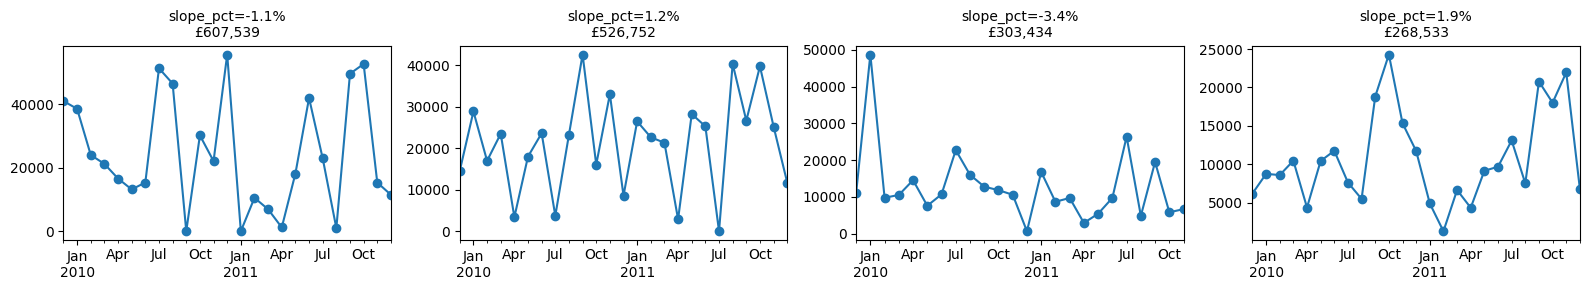

In [38]:
import matplotlib.pyplot as plt

# Pull 4 random declining Champions and plot their monthly trajectories
sample = customer
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

---
---
# Seasonality

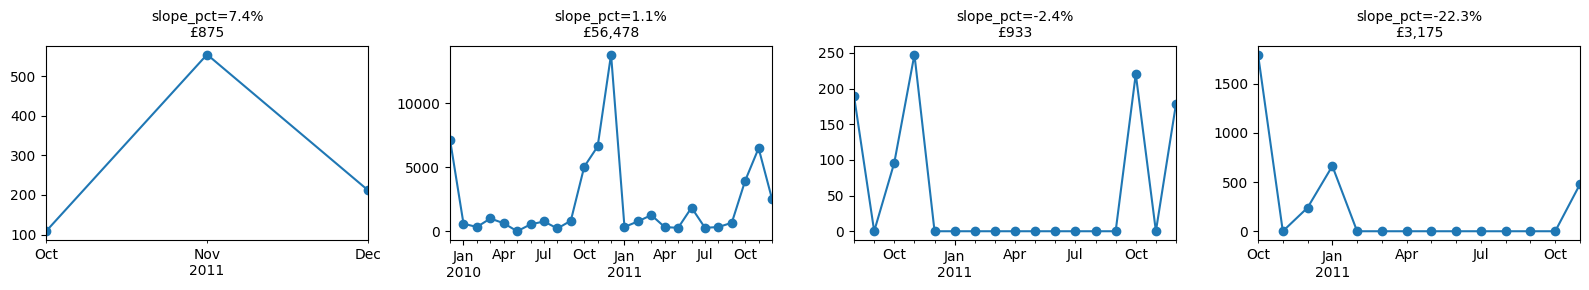

In [44]:
purchase_pattern = customer[(customer['seasonality_segment']=='Winter Specialist')]

import matplotlib.pyplot as plt

# Pull 4 random monthly trajectories
sample = purchase_pattern.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

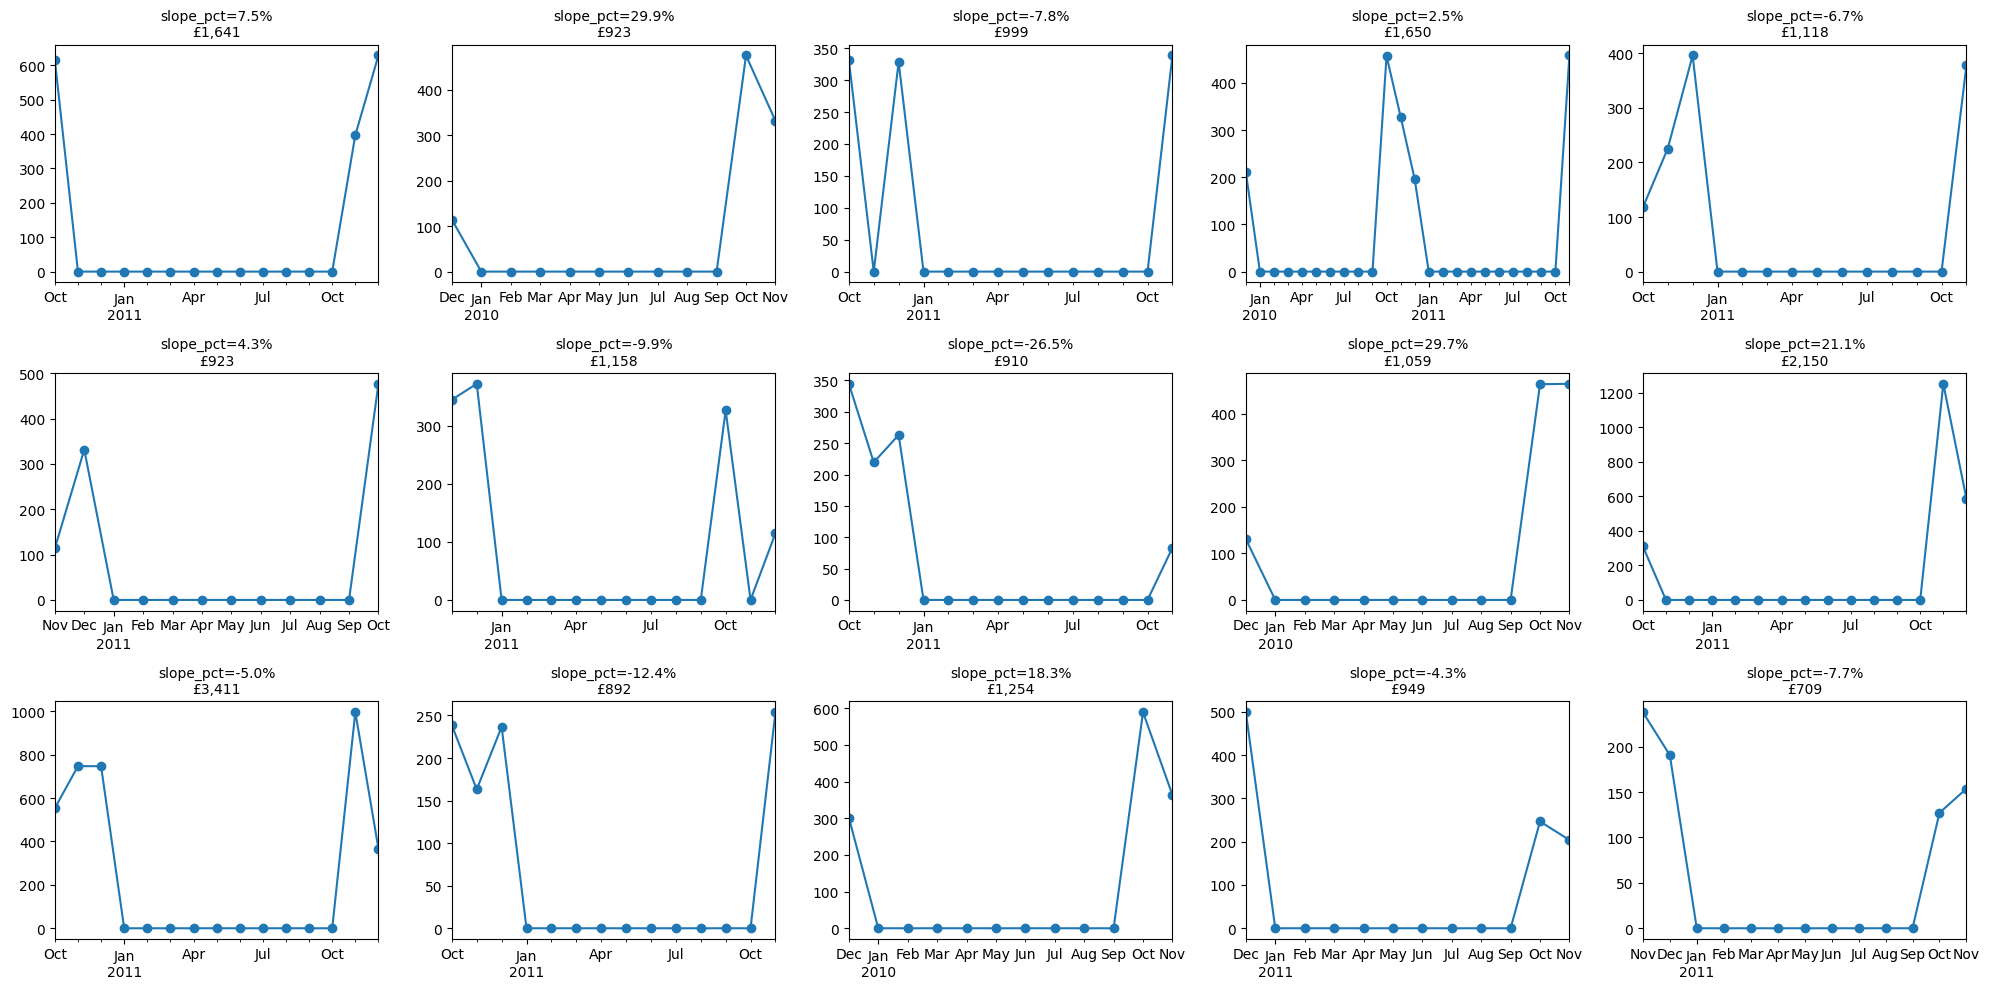

In [69]:
purchase_pattern = customer[customer['seasonality_segment'] == 'Winter Specialist']

import matplotlib.pyplot as plt

sample = purchase_pattern.sample(15, random_state=82)
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}",
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

---
---
## Manual build out of Seasonal Logic

In [14]:
invoice_count_by_month = (df.groupby([df['InvoiceDateMin'].dt.year.rename('Year'),
                                       df['InvoiceDateMin'].dt.month.rename('Month')])
                            .agg(n_invoices=('Invoice', 'nunique'),
                                 n_customers=('CustomerHashID', 'nunique'))
                            .reset_index()
                            .sort_values(['Year', 'Month']))
print(invoice_count_by_month)

    Year  Month  n_invoices  n_customers
0   2009     12        1490          949
1   2010      1         955          700
2   2010      2        1087          769
3   2010      3        1505         1050
4   2010      4        1311          939
5   2010      5        1351          961
6   2010      6        1473         1033
7   2010      7        1356          923
8   2010      8        1272          909
9   2010      9        1650         1133
10  2010     10        2101         1490
11  2010     11        2560         1603
12  2010     12        1384          883
13  2011      1         976          737
14  2011      2         988          756
15  2011      3        1307          972
16  2011      4        1128          851
17  2011      5        1538         1054
18  2011      6        1380          987
19  2011      7        1315          943
20  2011      8        1264          932
21  2011      9        1735         1257
22  2011     10        1889         1359
23  2011     11 

In [15]:
# ============================================================
# Sanity Check: TotalPrice <= 0 
# ============================================================

# 1. Count how many rows have a TotalPrice of 0 or less
mask_invalid_price = df['TotalPrice'] == 0
invalid_count = mask_invalid_price.sum()

print(f"Found {invalid_count} rows with TotalPrice == 0")

# 2. (Optional) View a sample of them to see what's going on (e.g., biscuit tins!)
if invalid_count > 0:
    print(df[mask_invalid_price][['CustomerHashID', 'InvoiceDateMin', 'TotalPrice']].head())

# 3. Cleanse the dataframe by keeping ONLY rows where TotalPrice > 0
# (Run this early in your script before generating customer['n_invoices'])
df = df[df['TotalPrice'] > 0].copy()

Found 73 rows with TotalPrice == 0
                                          CustomerHashID      InvoiceDateMin  \
4674   8b339ef1672c9ebf73858e4ed145c4a92ad8115f966d40... 2009-12-02 13:34:00   
6781   b6e99a08704d142e41b7764c739b4c1ffc5c30cdb56d0d... 2009-12-03 11:19:00   
18738  515b51a8eec565c3d6e7bee0c8ad895ca64e545621523e... 2009-12-08 15:25:00   
18739  515b51a8eec565c3d6e7bee0c8ad895ca64e545621523e... 2009-12-08 15:25:00   
32916  6cbb204f5eabab3ac1f73b1f04dc281cb2e7f33db05aa4... 2009-12-15 13:49:00   

       TotalPrice  
4674          0.0  
6781          0.0  
18738         0.0  
18739         0.0  
32916         0.0  


In [16]:
import pandas as pd

# ============================================================
# Initialise the purchase_behaviour field
# ============================================================
customer['purchase_behaviour'] = pd.NA 
customer['multiple_year_purchase'] = pd.NA 

# ============================================================
# Rule 1 — One-time purchasers
# ============================================================
mask_rule_1 = customer['n_invoices'] == 1
customer.loc[mask_rule_1, 'purchase_behaviour'] = 'One-Time Purchase'
customer.loc[mask_rule_1, 'multiple_year_purchase'] = False

# print(f"Rule 1 claimed: {mask.sum()} customers")
print(f"Rule 1 claimed: {mask_rule_1.sum()} customers")
# print(customer['purchase_behaviour'].value_counts(dropna=False))


# ============================================================
# Rule 2 — Yearly Repeat Purchase (2 Invoices, 11-12 month gap)
# or two year 23-24 gap
# ============================================================

# 1: Get a list of CustomerHashIDs who have exactly 2 invoices AND are unclassified
mask_2_invoices = (customer['n_invoices'] == 2) & (customer['purchase_behaviour'].isna())
eligible_ids = customer.loc[mask_2_invoices, 'CustomerHashID']

# 2: Filter the raw 'df' to only include line items for these specific customers
df_rule_2 = df[df['CustomerHashID'].isin(eligible_ids)]

# 3: Group by Customer to get the Date of Invoice 1 (min) and Invoice 2 (max)
df['InvoiceDateMin'] = pd.to_datetime(df['InvoiceDateMin']) 

customer_dates = df_rule_2.groupby('CustomerHashID')['InvoiceDateMin'].agg(['min', 'max'])

# 4: Calculate the gap in days
customer_dates['days_between'] = (customer_dates['max'] - customer_dates['min']).dt.days

# 5: Identify the customers where the gap is 11 to 12 months.
# 11 months is ~334 days. 12 months is ~365 days. we use 325, 375
mask_11_12_months = (customer_dates['days_between'] >= 325) & (customer_dates['days_between'] <= 375)
mask_23_24_months = (customer_dates['days_between'] >= 650) & (customer_dates['days_between'] <= 750) # add the following year

# 6: Extract just the IDs of the customers who passed this test
yearly_repeat_ids = customer_dates[mask_11_12_months].index
two_year_repeat_ids = customer_dates[mask_23_24_months].index

# 7: Update the customer table
mask_rule_2 = (customer['CustomerHashID'].isin(yearly_repeat_ids)) & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_2, 'purchase_behaviour'] = 'Yearly Same Month One-time Repeat Purchase'
customer.loc[mask_rule_2, 'multiple_year_purchase'] = True

mask_rule_2b = (customer['CustomerHashID'].isin(two_year_repeat_ids)) & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_2b, 'purchase_behaviour'] = 'Yearly Same Month One-time Repeat Purchase'
customer.loc[mask_rule_2b, 'multiple_year_purchase'] = True

print(f"Rule 2 claimed: {mask_rule_2.sum()} customers")
print(f"Rule 2b claimed: {mask_rule_2b.sum()} customers")


# ============================================================
# Rule 3 — Adhoc Purchase (2 Invoices, 4-10 month gap)
# or two year 16-22 gap
# ============================================================

# 4 months is ~120 days. < 11 months is ~324 days.
mask_4_10_months = (customer_dates['days_between'] >= 115) & (customer_dates['days_between'] <= 324)
mask_16_22_months = (customer_dates['days_between'] >= 375) & (customer_dates['days_between'] <= 684)

adhoc_ids = customer_dates[mask_4_10_months].index
two_year_adhoc_ids = customer_dates[mask_16_22_months].index

mask_rule_3 = (customer['CustomerHashID'].isin(adhoc_ids))  & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_3, 'purchase_behaviour'] = 'Yearly Adhoc One-time Repeat Purchase'
customer.loc[mask_rule_3, 'multiple_year_purchase'] = True

mask_rule_3b = (customer['CustomerHashID'].isin(two_year_adhoc_ids))  & (customer['purchase_behaviour'].isna())
customer.loc[mask_rule_3b, 'purchase_behaviour'] = 'Yearly Adhoc One-time Repeat Purchase'

print(f"Rule 3 claimed: {mask_rule_3.sum()} customers")
print(f"Rule 3b claimed: {mask_rule_3b.sum()} customers")
customer.loc[mask_rule_3b, 'multiple_year_purchase'] = True


# ============================================================
# Rule 4 — Split-Order Purchases (<= 35 days act like One-Timers)
# ============================================================


mask_same_month_order = (customer_dates['days_between'] <= 35)
same_month_order_ids = customer_dates[mask_same_month_order].index

mask_rule_4 = (customer['CustomerHashID'].isin(same_month_order_ids)) & (customer['purchase_behaviour'].isna())

# Give them the same label as Rule 1
customer.loc[mask_rule_4, 'purchase_behaviour'] = 'One-Time Purchase'
customer.loc[mask_rule_4, 'multiple_year_purchase'] = False

print(f"Rule 4 claimed: {mask_rule_4.sum()} customers")



# ============================================================
# How many from the 2 invoice rule are left to classify

# Create a mask for remaining 2-invoice customers
mask_leftover_2_invoices = (customer['n_invoices'] == 2) & (customer['purchase_behaviour'].isna())

# Print the count
print(f"Remaining unclassified 2-invoice customers: {mask_leftover_2_invoices.sum()}")


# ============================================================
# Graph see the results, how many NA are left to categorise
# ============================================================

summary = customer['purchase_behaviour'].value_counts(dropna=False).to_frame(name='count')

# Add the percentage column
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100

# Print (rounded to 1 decimal places)
print(summary.round(1))

# Print summary of multiple_year_purchase column
print("\n--- Multiple Year Purchase Summary ---")
print(customer['multiple_year_purchase'].value_counts(dropna=False))

Rule 1 claimed: 1619 customers
Rule 2 claimed: 84 customers
Rule 2b claimed: 7 customers
Rule 3 claimed: 285 customers
Rule 3b claimed: 103 customers
Rule 4 claimed: 225 customers
Remaining unclassified 2-invoice customers: 244
                                            count  percentage
purchase_behaviour                                           
<NA>                                         3526        60.3
One-Time Purchase                            1844        31.5
Yearly Adhoc One-time Repeat Purchase         388         6.6
Yearly Same Month One-time Repeat Purchase     91         1.6

--- Multiple Year Purchase Summary ---
multiple_year_purchase
<NA>     3526
False    1844
True      479
Name: count, dtype: int64


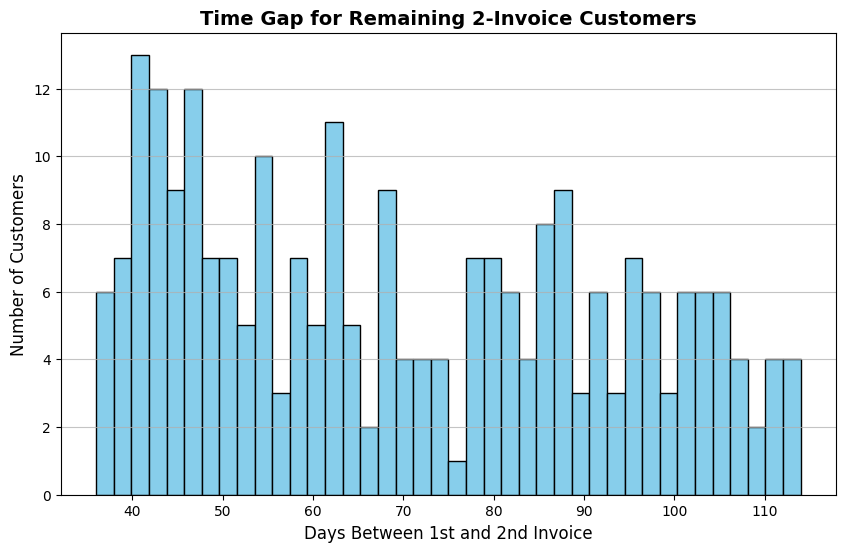

In [16]:
import matplotlib.pyplot as plt

# 1. Isolate the 2-invoice customers who are still unclassified
mask_leftover_2_invoices = (customer['n_invoices'] == 2) & (customer['purchase_behaviour'].isna())
leftover_ids = customer.loc[mask_leftover_2_invoices, 'CustomerHashID']

# 2. Get their 'days_between' data from the customer_dates table we made earlier
leftovers_data = customer_dates[customer_dates.index.isin(leftover_ids)]

# 3. Create the Matplotlib Histogram
plt.figure(figsize=(10, 6)) # Makes the chart a nice wide rectangle

# We use bins=40 to slice the data into small buckets (roughly 1-2 weeks each)
plt.hist(leftovers_data['days_between'], bins=40, color='skyblue', edgecolor='black')

plt.title('Time Gap for Remaining 2-Invoice Customers', fontsize=14, fontweight='bold')
plt.xlabel('Days Between 1st and 2nd Invoice', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# This adds a grid behind the bars to make it easier to read
plt.grid(axis='y', alpha=0.75) 

# Show the plot!
plt.show()

In [17]:
# ============================================================
# Setting up the 9-Quarter Matrix (For >= 2 Invoices)
# ============================================================

# 1. Filter: Unclassified AND n_invoices >= 2
mask_2_plus = (customer['purchase_behaviour'].isna()) & (customer['n_invoices'] >= 2)
unclassified_2_plus_ids = customer.loc[mask_2_plus, 'CustomerHashID']

# 2. Filter raw 'df' to just these remaining customers
df_seasonal = df[df['CustomerHashID'].isin(unclassified_2_plus_ids)].copy()

# 3. Create the '2009_Q4' format! 
# We combine the Year as a string, add '_Q', and then the Quarter as a string
df_seasonal['Year_Quarter'] = (
    df_seasonal['InvoiceDateMin'].dt.year.astype(str) + '_Q' + 
    df_seasonal['InvoiceDateMin'].dt.quarter.astype(str)
)

# 4. Create the Matrix using our new Year_Quarter column
q_matrix = pd.crosstab(df_seasonal['CustomerHashID'], df_seasonal['Year_Quarter'])

# 5. Convert counts to 1 (Yes) or 0 (No)
q_matrix = (q_matrix > 0).astype(int)

# 6. Force the matrix to have exactly your 9 columns in the right order. 
# (This prevents errors if nobody happened to buy in 2009_Q4)
expected_columns = [
    '2009_Q4', '2010_Q1', '2010_Q2', '2010_Q3', '2010_Q4', 
    '2011_Q1', '2011_Q2', '2011_Q3', '2011_Q4'
]
q_matrix = q_matrix.reindex(columns=expected_columns, fill_value=0)

# 7. Convert the 9 columns of 1s and 0s into a single string for each customer
q_matrix['pattern'] = q_matrix[expected_columns].astype(str).agg(''.join, axis=1)

print("B2B 9-Quarter Matrix")
print(q_matrix.head())

B2B 9-Quarter Matrix
Year_Quarter                                        2009_Q4  2010_Q1  2010_Q2  \
CustomerHashID                                                                  
00189f7baec2462e442b86d14102254df902adc5accc25e...        0        0        0   
002403301211297ae25ec229d6751c749330628e52940b7...        0        1        1   
0029315aefcd3710655f212f0d3b621343af84f1cf7aee2...        0        0        0   
0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b1...        0        0        0   
004881fba4811a24c786f19fb16c3cf49073ac62c60c85f...        1        1        1   

Year_Quarter                                        2010_Q3  2010_Q4  2011_Q1  \
CustomerHashID                                                                  
00189f7baec2462e442b86d14102254df902adc5accc25e...        0        0        0   
002403301211297ae25ec229d6751c749330628e52940b7...        1        1        1   
0029315aefcd3710655f212f0d3b621343af84f1cf7aee2...        0        0        1   
0036e0

In [18]:
# ============================================================
# Import the completed Excel/CSV mapping (Fixed for 2 Labels)
# ============================================================

# 1. Read the CSV you mapped in Excel
mapping_df = pd.read_csv('patterns.csv')

# 2. Ensure patterns are strings and exactly 9 characters long 
mapping_df['pattern'] = mapping_df['pattern'].astype(str).str.zfill(9)

# 3. Drop any rows that are blank in Excel
mapping_df = mapping_df.dropna(subset=['purchase_behaviour'])

# 4. Make two dictionaries
dict_behaviour = dict(zip(mapping_df['pattern'], mapping_df['purchase_behaviour']))
dict_repetition = dict(zip(mapping_df['pattern'], mapping_df['multiple_year_purchase']))

# 5. Map them to the q_matrix
q_matrix['purchase_behaviour'] = q_matrix['pattern'].map(dict_behaviour)
q_matrix['multiple_year_purchase'] = q_matrix['pattern'].map(dict_repetition)

# 6. Apply back to the main 'customer' table
# Convert matrix columns to {CustomerHashID: value} dictionaries
matched_dict_behaviour = q_matrix['purchase_behaviour'].dropna().to_dict()
matched_dict_repetition = q_matrix['multiple_year_purchase'].dropna().to_dict()

# Create mask: Only update if currently unclassified and we found a match in the dictionary
mask_truth_table = customer['purchase_behaviour'].isna() & customer['CustomerHashID'].isin(matched_dict_behaviour.keys())

# Update the main behaviour column
customer.loc[mask_truth_table, 'purchase_behaviour'] = customer.loc[mask_truth_table, 'CustomerHashID'].map(matched_dict_behaviour)

# Add/Update repetition flag column in the customer table
customer.loc[mask_truth_table, 'multiple_year_purchase'] = customer.loc[mask_truth_table, 'CustomerHashID'].map(matched_dict_repetition)

print(f"Excel Truth Table mapped {mask_truth_table.sum()} customers.")

Excel Truth Table mapped 3526 customers.


In [19]:
summary = customer['purchase_behaviour'].value_counts(dropna=False).to_frame(name='count')

# Add the percentage column
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100

# Print (rounded to 1 decimal places)
print(summary.round(1))

                                            count  percentage
purchase_behaviour                                           
Year-round Purchase                          2254        38.5
One-Time Purchase                            1844        31.5
Yearly Adhoc One-time Repeat Purchase         388         6.6
H2 Purchase                                   353         6.0
Spring-Winter Purchase                        190         3.2
Winter-Peak Purchase                          182         3.1
Winter Season Purchase                        157         2.7
Spring-Summer Purchase                        153         2.6
H1 Purchase                                   102         1.7
Yearly Same Month One-time Repeat Purchase     91         1.6
New-Year Summer Purchase                       57         1.0
Summer-Season Purchase                         34         0.6
New-Year Purchase                              26         0.4
Spring-Season Purchase                         18         0.3


---
# Export data
---
---

**We push dataframe customer to folder data/procesed, file B2B_customer_segmentation.parquet:**

In [20]:
# 1. Convert all text columns to 'string' dtype (safe for SQL)
text_cols = ['CustomerHashID', 'country_mode', 'region', 'sub_region', 
             'RFM_cell', 'lifecycle_segment', 'historical_value_tier', 'current_value_tier', 'trajectory', 
             'purchase_behaviour']

for col in text_cols:
    customer[col] = customer[col].astype('string')

# 2. Fix the Boolean columns (in case they are text "TRUE"/"FALSE")
bool_cols = ['repeat_customer', 'is_left_censored', 'multiple_year_purchase']

for col in bool_cols:
    # If they are already bools, this won't hurt them. If they are text, it fixes them.
    if customer[col].dtype == 'object' or str(customer[col].dtype) == 'string':
        customer[col] = customer[col].astype(str).str.upper().map({'TRUE': True, 'FALSE': False})
    
    customer[col] = customer[col].astype('boolean')

In [21]:
import os
# We use parquet format to preserve datatypes in the output file
# run pip install pyarrow in terminal if you don't have it

# Define the output path for the transformed data
output_parquet_path = '../data/processed/B2B_customer_segmentation.parquet'
output_dir = os.path.dirname(output_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(output_dir):
    print(f"❌ ERROR: The directory '{output_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(output_parquet_path):
    print(f"⏳ Exporting customer segmentation data to {output_parquet_path} ..")
    customer.to_parquet(output_parquet_path, index=False)
    print("✅ Export complete.")

# 3. If file already exists, skip the export and advise to review.
else:
    print(f"❌ File '{output_parquet_path}' already exists.")
    print("  .. Skipping export.")
    print("  Please review/delete existing file, prior to re-running this cell.")

⏳ Exporting customer segmentation data to ../data/processed/B2B_customer_segmentation.parquet ..
✅ Export complete.


---
# Table Specifications
---
---

#### **Table name:** B2B_customer_segmentation
- Fields: 45
- Rows: 5,849
- File Size: 1.1 MB
- Approximate Memory Use: 2.8 MB

| **Field** | **Description** | **Data Type** | **Example** |
| :--- | :--- | :--- | :--- |
| CustomerHashID | Pseudonymised customer number | String | 09c72970956ea... |
| n_invoices | Number of invoices | Int64 | 145 |
| n_lines | Number of line items | Int64 | 1056 |
| n_skus | Number of unique stock units | Int64 | 382 |
| total_qty | Total number of products | Int64 | 188060 |
| total_revenue | Total revenue of all purchases | Float64 | 607539.25 |
| ltm_revenue | Last 12 month revenue of purchases | Float64 | 307539.25 |
| avg_qty_per_line | Average number of products per line item | Float64 | 178.0 |
| median_qty_per_line | Median number of products per line item | Float64 | 120.0 |
| max_qty_per_line | Max number of products per line item | Int64 | 1008 |
| first_purchase | First date of purchase | Datetime64 | 2009-12-01 09:24:00 |
| last_purchase | Last date of purchase | Datetime64 | 2011-12-09 11:50:00 |
| n_countries | Number of different countries shipped to | Int64 | 1 |
| avg_basket_breadth | Average number of different products per invoice | Float64 | 7.15 |
| avg_basket_value | Average revenue per basket | Float64 | 4189.9 |
| avg_basket_qty | Average number of items per basket | Float64 | 1296.9 |
| avg_item_value | Average item price = total revenue over quantity | Float64 | 3.90 |
| active_span_days | Days between first and last purchase | Int64 | 738 |
| orders_per_month | Average number of orders per month | Float64 | 5.98 |
| recency_days | Days since last purchase | Int64 | 10 |
| repeat_customer | Flag for returning customers | Boolean | True |
| cohort_month | Month of customer's first purchase | Period(M) | 2010-09 |
| is_left_censored | Flag for customers existing prior to dataset start | Boolean | False |
| pct_case_pack_wholesale| Percentage of items bought in wholesale multiples | Float64 | 0.29 |
| pct_case_pack_metric | Percentage of items bought in metric multiples | Float64 | 0.08 |
| pct_case_pack_total | Total percentage of pack multiples | Float64 | 0.37 |
| pct_business_hours | Percentage of orders made during business hours | Float64 | 0.88 |
| pct_after_hours_wkday | Percentage of orders made during evening hours | Float64 | 0.10 |
| pct_weekend | Percentage of orders made on the weekend | Float64 | 0.02 |
| country_mode | Most frequent country of purchase | String | IRELAND |
| rev_slope | Linear trend of revenue over active months | Float64 | -270.76 |
| rev_slope_pct | Percentage trend of revenue over active months | Float64 | -0.01 |
| n_active_months | Number of distinct months with a purchase | Int64 | 13 |
| region | Broad geographic region | String | APAC |
| sub_region | Specific geographic sub-region | String | OCEANIA |
| R | Recency score (1-5) | Int64 | 5 |
| F | Frequency score (1-5) | Int64 | 4 |
| M | Monetary score (1-5) | Int64 | 5 |
| RFM_score | Combined R + F + M score (Sum) | Int64 | 14 |
| RFM_cell | Combined R + F + M cell (Concatenation) | String | 545 |
| lifecycle_segment | Behavioral customer segmentation | String | Champions |
| hist_cum_rev_pct | Cumulative total revenue percentile | Float64 | 0.37 |
| historical_value_tier | Full Value tier based on 80/20 Pareto rule | String | Key Account |
| curr_cum_rev_pct | Cumulative 12 month revenue percentile | Float64 | 0.83 |
| current_value_tier | Current Value tier based on 80/20 Pareto rule | String | Core Account |
| trajectory | Customer spend momentum (Growing/Stable/Declining) | String | Growing |
| purchase_behaviour | Customer seasonality profile | String | Year-round |
| multiple_year_purchase | Made purchases in more than one calendar year | Boolean | True |

In [22]:
# Check column names, data types, and non-null counts
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 5849 entries, 0 to 5848
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerHashID           5849 non-null   string        
 1   n_invoices               5849 non-null   int64         
 2   n_lines                  5849 non-null   int64         
 3   n_skus                   5849 non-null   int64         
 4   total_qty                5849 non-null   int64         
 5   total_revenue            5849 non-null   float64       
 6   ltm_revenue              5849 non-null   float64       
 7   avg_qty_per_line         5849 non-null   float64       
 8   median_qty_per_line      5849 non-null   float64       
 9   max_qty_per_line         5849 non-null   int64         
 10  first_purchase           5849 non-null   datetime64[us]
 11  last_purchase            5849 non-null   datetime64[us]
 12  n_countries              5849 non-null   int6